# 03 — Training, Calibration & Blind Evaluation

**Objective:** Train classical ML models (GBDT + Linear SVM) on 33 handcrafted forensic features,
calibrate the champion model via Platt Scaling, lock an operating threshold, and perform
**blind** evaluation on ID-Test and OOD suites — all under a strict anti-leakage protocol.

---

## Source of Truth & Assumptions

| Document | Key Extraction |
|----------|----------------|
| `p0.txt` | FPR ≤ 5 % on OOD REAL, TPR ≥ 95 % on AI test, ECE ≤ 0.05, Brier ≤ 0.1 |
| `p1.txt §1.1-1.3` | 5 ID generators (ADM, Midjourney, SDv14, VQDM, Wukong); 2 OOD hold-out (SDv15, GLIDE); split 48k/6k/6k; calibration 3 000 from train |
| `p1.txt §3.4` | Platt Scaling on dedicated calibration set; **never** fit on val |
| `solution.txt` | GBDT/SVM + Platt; MEDIUM zone for uncertain scores |
| `preprocessing.txt` | .npy 256×256×3 YCrCb BT.601; JPEG bottleneck Q∈[90,98]; DCT grid misaligned +3px |
| `feature.txt` | 4 groups, 33 features; Group 4 may produce NaN (physical dead signal) |

### Assumptions & Conservative Decisions

1. **`split_role` is pre-assigned** in `features_dataset.csv` by notebook 02 (seed=42, stratified by generator×label).
   We trust this column as the single source of truth for partitioning.
2. **External OOD datasets (AIGIBench, COCOFake, CIFAKE) are not yet in the workspace.**
   The notebook will detect their absence, log it clearly, and evaluate only on GenImage OOD (SDv15 + GLIDE).
3. **Class-level split** was requested by spec §1.3 but ImageNet class labels are unavailable for
   `ILSVRC2012_val_*` nature images. Image-level stratified split (by generator×label) was used as a safe fallback.
   This is a **known limitation** logged in the risk register.
4. **Group 4 NaN** is physical (flat-zone dead signal per spec). Handled via Dual-Imputation:
   - GBDT path: native NaN support (LightGBM)
   - SVM path: median imputation + binary indicators, fit on train_core only
5. **No benchmark fishing.** Champion is selected on val. Threshold is locked on val. OOD is blind.

### Anti-Leakage Rules (enforced by assertions)

| Rule | Enforcement |
|------|-------------|
| OOD never enters any `.fit()` | Hard assert after every fit call |
| Imputer/Scaler fit on train_core only | Explicit `fit(X_train)` then `transform(X_other)` |
| Calibrator fit on calibration set only | Separate from val (no double-dipping) |
| Threshold locked on val only | `tau_op` frozen before seeing id_test or OOD |
| Constant pruning on train_core only | `pruned_features` list applied uniformly |
| Champion selection before OOD | Selected on val metrics, OOD is blind |

## Cell 1 — Imports, Config & Random Seed

In [2]:
"""Cell 1 — Imports, Config & Random Seed."""
from __future__ import annotations

import json
import logging
import os
import sys
import warnings
from pathlib import Path
from typing import Any

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ── Project paths ────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FEATURES_CSV = PROJECT_ROOT / "features" / "features_dataset.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "models" / "03_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────────────
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# ── Logging ──────────────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger("03_training")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

# ── Feature schema (from spec) ────────────────────────────────────────
GROUP1_FREQ = ["frs_mid_variance", "dct_mid_mean", "dct_mid_variance",
               "dct_mid_skewness", "ps_alpha", "ps_deviation_variance"]
GROUP2_COLOR = ["local_color_inconsistency", "pearson_y_cr", "pearson_y_cb",
                "pearson_cr_cb", "energy_ratio_chroma", "glcm_contrast_cr",
                "glcm_correlation_cr", "glcm_energy_cr", "glcm_homogeneity_cr"]
GROUP3_MICRO = ["srm_square3_mar_cr", "srm_square3_energy_cr", "srm_edge3_mar_cr",
                "srm_edge3_energy_cr", "srm_square5_mar_cr", "srm_square5_energy_cr",
                "lbp_nonuniform_ratio_cr", "lbp_entropy_cr",
                "lbp_nonuniform_ratio_cb", "lbp_entropy_cb"]
GROUP4_SPATIAL = ["spatial_snr_ratio", "cross_noise_ratio",
                  "skew_noise_y", "kurt_noise_y",
                  "skew_noise_cr", "kurt_noise_cr",
                  "skew_noise_cb", "kurt_noise_cb"]

ALL_FEATURE_KEYS = GROUP1_FREQ + GROUP2_COLOR + GROUP3_MICRO + GROUP4_SPATIAL
NAN_CAPABLE_FEATURES = GROUP4_SPATIAL  # spec: Group 4 may produce NaN
GUARANTEED_FINITE = GROUP1_FREQ + GROUP2_COLOR + GROUP3_MICRO

# Valid split roles
VALID_ROLES = {"train_core", "calibration", "val", "id_test", "ood_eval"}

# OOD generators
OOD_GENERATORS = {"SDv15", "GLIDE"}
ID_GENERATORS = {"ADM", "Midjourney", "SDv14", "VQDM", "Wukong"}

print(f"✓ Project root  : {PROJECT_ROOT}")
print(f"✓ Features CSV  : {FEATURES_CSV}")
print(f"✓ Artifacts dir : {ARTIFACTS_DIR}")
print(f"✓ Feature count : {len(ALL_FEATURE_KEYS)} (G1={len(GROUP1_FREQ)}, G2={len(GROUP2_COLOR)}, G3={len(GROUP3_MICRO)}, G4={len(GROUP4_SPATIAL)})")
print(f"✓ NaN-capable   : {len(NAN_CAPABLE_FEATURES)} features (Group 4)")
print(f"✓ Global seed   : {GLOBAL_SEED}")

✓ Project root  : c:\Users\USER\OneDrive\Máy tính\ai_detector_img
✓ Features CSV  : c:\Users\USER\OneDrive\Máy tính\ai_detector_img\features\features_dataset.csv
✓ Artifacts dir : c:\Users\USER\OneDrive\Máy tính\ai_detector_img\models\03_artifacts
✓ Feature count : 33 (G1=6, G2=9, G3=10, G4=8)
✓ NaN-capable   : 8 features (Group 4)
✓ Global seed   : 42


## Cell 2 — Dataset Loading & Schema Validation

In [3]:
"""Cell 2 — Dataset Loading & Schema Validation."""

assert FEATURES_CSV.exists(), f"Features CSV not found: {FEATURES_CSV}"
df_full = pd.read_csv(FEATURES_CSV)
print(f"Loaded: {df_full.shape[0]:,} rows × {df_full.shape[1]} columns")

# ── Schema validation ─────────────────────────────────────────────────
REQUIRED_META = ["file_path", "generator", "label", "split_role"]
REQUIRED_STATUS = ["status"]

missing_meta = [c for c in REQUIRED_META if c not in df_full.columns]
missing_feat = [c for c in ALL_FEATURE_KEYS if c not in df_full.columns]
assert not missing_meta, f"Missing metadata columns: {missing_meta}"
assert not missing_feat, f"Missing feature columns: {missing_feat}"

# ── Filter to status=ok only ──────────────────────────────────────────
n_err = (df_full["status"] != "ok").sum()
if n_err > 0:
    logger.warning("Dropping %d rows with status != 'ok'", n_err)
df = df_full[df_full["status"] == "ok"].copy()
print(f"After status filter: {len(df):,} rows (dropped {n_err})")

# ── Validate split_role ──────────────────────────────────────────────
actual_roles = set(df["split_role"].unique())
assert actual_roles == VALID_ROLES, f"Unexpected split_roles: {actual_roles} vs expected {VALID_ROLES}"

# ── Encode label: nature=0 (REAL), ai=1 (FAKE) ──────────────────────
assert set(df["label"].unique()) == {"ai", "nature"}, f"Unexpected labels: {df['label'].unique()}"
df["y"] = (df["label"] == "ai").astype(int)

# ── Split distribution ────────────────────────────────────────────────
print("\nSplit distribution:")
for role in ["train_core", "calibration", "val", "id_test", "ood_eval"]:
    sub = df[df["split_role"] == role]
    n_real = (sub["y"] == 0).sum()
    n_fake = (sub["y"] == 1).sum()
    print(f"  {role:14s}: {len(sub):>6,}  (real={n_real:,}, fake={n_fake:,})")

Loaded: 87,971 rows × 42 columns
After status filter: 87,971 rows (dropped 0)

Split distribution:
  train_core    : 45,590  (real=22,790, fake=22,800)
  calibration   :  2,400  (real=1,200, fake=1,200)
  val           :  6,000  (real=3,000, fake=3,000)
  id_test       :  6,000  (real=3,000, fake=3,000)
  ood_eval      : 27,981  (real=13,989, fake=13,992)


## Cell 3 — OOD Physical Isolation & Leakage Guard

In [4]:
"""Cell 3 — OOD Physical Isolation & Leakage Guard."""

# ── Create split DataFrames ──────────────────────────────────────────
df_train = df[df["split_role"] == "train_core"].copy()
df_cal   = df[df["split_role"] == "calibration"].copy()
df_val   = df[df["split_role"] == "val"].copy()
df_test  = df[df["split_role"] == "id_test"].copy()
df_ood   = df[df["split_role"] == "ood_eval"].copy()

# ── Hard leakage assertions ──────────────────────────────────────────
# Rule 1: OOD generators must ONLY appear in ood_eval
for role, sub in [("train_core", df_train), ("calibration", df_cal),
                   ("val", df_val), ("id_test", df_test)]:
    leaked = sub[sub["generator"].isin(OOD_GENERATORS)]
    assert len(leaked) == 0, f"LEAKAGE: {len(leaked)} OOD rows in {role}!"

# Rule 2: ID generators must NOT appear in ood_eval
leaked_id = df_ood[df_ood["generator"].isin(ID_GENERATORS)]
assert len(leaked_id) == 0, f"LEAKAGE: {len(leaked_id)} ID rows in ood_eval!"

# Rule 3: No row appears in multiple splits
all_paths = pd.concat([df_train["file_path"], df_cal["file_path"],
                        df_val["file_path"], df_test["file_path"],
                        df_ood["file_path"]])
assert all_paths.nunique() == len(all_paths), "Duplicate file_path across splits!"
assert len(all_paths) == len(df), f"Split accounting error: {len(all_paths)} vs {len(df)}"

print(f"✓ Leakage guard: PASS")
print(f"  train_core  : {len(df_train):>6,} rows | generators: {sorted(df_train['generator'].unique())}")
print(f"  calibration : {len(df_cal):>6,} rows | generators: {sorted(df_cal['generator'].unique())}")
print(f"  val         : {len(df_val):>6,} rows | generators: {sorted(df_val['generator'].unique())}")
print(f"  id_test     : {len(df_test):>6,} rows | generators: {sorted(df_test['generator'].unique())}")
print(f"  ood_eval    : {len(df_ood):>6,} rows | generators: {sorted(df_ood['generator'].unique())}")

# ── Log external OOD datasets status ─────────────────────────────────
print("\nExternal OOD datasets status:")
for name in ["AIGIBench", "COCOFake", "CIFAKE"]:
    present = df[df.get("dataset_name", pd.Series(dtype=str)) == name] if "dataset_name" in df.columns else pd.DataFrame()
    has_rows = len(present[present["dataset_name"] == name]) if "dataset_name" in df.columns and len(present) > 0 else 0
    status = f"{has_rows:,} rows" if has_rows > 0 else "ABSENT — not in features_dataset.csv"
    print(f"  {name:12s}: {status}")
print("  → Only GenImage OOD (SDv15 + GLIDE) available for blind evaluation.")

✓ Leakage guard: PASS
  train_core  : 45,590 rows | generators: ['ADM', 'Midjourney', 'SDv14', 'VQDM', 'Wukong']
  calibration :  2,400 rows | generators: ['ADM', 'Midjourney', 'SDv14', 'VQDM', 'Wukong']
  val         :  6,000 rows | generators: ['ADM', 'Midjourney', 'SDv14', 'VQDM', 'Wukong']
  id_test     :  6,000 rows | generators: ['ADM', 'Midjourney', 'SDv14', 'VQDM', 'Wukong']
  ood_eval    : 27,981 rows | generators: ['GLIDE', 'SDv15']

External OOD datasets status:
  AIGIBench   : ABSENT — not in features_dataset.csv
  COCOFake    : ABSENT — not in features_dataset.csv
  CIFAKE      : ABSENT — not in features_dataset.csv
  → Only GenImage OOD (SDv15 + GLIDE) available for blind evaluation.


## Cell 4 — Cross-Leakage Audit

In [5]:
"""Cell 4 — Cross-Leakage Audit."""

# Check if class_or_prompt_family column exists for class-level audit
has_class_col = "class_or_prompt_family" in df.columns

if has_class_col:
    train_classes = set(df_train["class_or_prompt_family"].dropna().unique())
    test_classes  = set(df_test["class_or_prompt_family"].dropna().unique())
    ood_classes   = set(df_ood["class_or_prompt_family"].dropna().unique())
    
    overlap_id = train_classes & test_classes
    overlap_ood = train_classes & ood_classes
    
    print(f"Class-level leakage audit:")
    print(f"  train ∩ id_test : {len(overlap_id)} overlapping classes")
    print(f"  train ∩ ood_eval: {len(overlap_ood)} overlapping classes")
else:
    print("⚠ LIMITATION: 'class_or_prompt_family' column not available in features_dataset.csv")
    print("  Cannot perform class-level cross-leakage audit.")
    print("  Mitigation: split was stratified by generator×label (not random image-level).")
    print("  Future: integrate ImageNet synset mapping for class-level split.")

# File-path-level audit (always possible)
train_paths = set(df_train["file_path"])
test_paths  = set(df_test["file_path"])
ood_paths   = set(df_ood["file_path"])

assert len(train_paths & test_paths) == 0, "File leakage: train_core ∩ id_test"
assert len(train_paths & ood_paths) == 0, "File leakage: train_core ∩ ood_eval"
print(f"\n✓ File-path leakage: 0 overlap (train∩test=0, train∩ood=0)")

⚠ LIMITATION: 'class_or_prompt_family' column not available in features_dataset.csv
  Cannot perform class-level cross-leakage audit.
  Mitigation: split was stratified by generator×label (not random image-level).
  Future: integrate ImageNet synset mapping for class-level split.

✓ File-path leakage: 0 overlap (train∩test=0, train∩ood=0)


## Cell 5 — Train-Core-Only QC, Missingness Audit & Constant Pruning

All statistics computed **only on `train_core`**. No OOD data touches any decision here.

In [6]:
"""Cell 5 — Train-Core-Only QC, Missingness & Constant Pruning."""

X_train_raw = df_train[ALL_FEATURE_KEYS]

# ══════════════════════════════════════════════════════════════════════
#  5A — Finiteness check (Group 1-3 must be finite)
# ══════════════════════════════════════════════════════════════════════
for g_name, g_keys in [("Group1_freq", GROUP1_FREQ), ("Group2_color", GROUP2_COLOR),
                        ("Group3_micro", GROUP3_MICRO)]:
    inf_count = (~np.isfinite(X_train_raw[g_keys])).sum().sum()
    assert inf_count == 0, f"{g_name} has {inf_count} non-finite values in train_core!"
print("✓ Groups 1-3: all finite in train_core")

# ══════════════════════════════════════════════════════════════════════
#  5B — Group 4 NaN audit (physical dead-signal per spec)
# ══════════════════════════════════════════════════════════════════════
print("\nGroup 4 NaN budget (train_core):")
nan_report = {}
for feat in NAN_CAPABLE_FEATURES:
    n_nan = X_train_raw[feat].isna().sum()
    pct = 100 * n_nan / len(X_train_raw)
    nan_report[feat] = {"n_nan": int(n_nan), "pct": round(pct, 2)}
    flag = f" ← {pct:.1f}% NaN" if n_nan > 0 else ""
    print(f"  {feat:32s}: {n_nan:>5,} NaN{flag}")

# ══════════════════════════════════════════════════════════════════════
#  5C — Missingness bias audit by generator
# ══════════════════════════════════════════════════════════════════════
print("\nMissingness by generator (train_core, Group 4 features):")
miss_by_gen = df_train.groupby("generator")[NAN_CAPABLE_FEATURES].apply(
    lambda g: g.isna().mean().mean() * 100
).round(2)
train_avg_miss = X_train_raw[NAN_CAPABLE_FEATURES].isna().mean().mean() * 100
print(f"  Overall train_core avg: {train_avg_miss:.2f}%")
risk_table = []
for gen, pct in miss_by_gen.items():
    flag = "⚠ RISK" if abs(pct - train_avg_miss) > 20 else ""
    print(f"  {gen:14s}: {pct:.2f}% {flag}")
    if flag:
        risk_table.append({"generator": gen, "miss_pct": pct, "note": ">20% deviation from train avg"})

# Also audit OOD missingness (read-only, no decision)
print("\nMissingness by generator (ood_eval, read-only audit):")
ood_miss = df_ood.groupby("generator")[NAN_CAPABLE_FEATURES].apply(
    lambda g: g.isna().mean().mean() * 100
).round(2)
for gen, pct in ood_miss.items():
    flag = "⚠ RISK" if abs(pct - train_avg_miss) > 20 else ""
    print(f"  {gen:14s}: {pct:.2f}% {flag}")

# ══════════════════════════════════════════════════════════════════════
#  5D — Exact-zero sentinel audit (Group 2, 3)
# ══════════════════════════════════════════════════════════════════════
print("\nExact-zero mass audit (train_core):")
sentinel_suspects = ["local_color_inconsistency", "energy_ratio_chroma",
                     "lbp_nonuniform_ratio_cr", "lbp_nonuniform_ratio_cb"]
for feat in sentinel_suspects:
    n_zero = (X_train_raw[feat] == 0.0).sum()
    pct = 100 * n_zero / len(X_train_raw)
    flag = f" ← {pct:.1f}% exact zero" if n_zero > 0 else ""
    print(f"  {feat:36s}: {n_zero:>5,}{flag}")

# ══════════════════════════════════════════════════════════════════════
#  5E — Constant feature pruning (train_core only)
# ══════════════════════════════════════════════════════════════════════
variances = X_train_raw.var()
CONST_THRESHOLD = 1e-15
pruned_features = variances[variances < CONST_THRESHOLD].index.tolist()

if pruned_features:
    print(f"\n⚠ Pruning {len(pruned_features)} constant features: {pruned_features}")
else:
    print(f"\n✓ No constant features (all variance > {CONST_THRESHOLD:.0e})")

# Active features after pruning
active_features = [f for f in ALL_FEATURE_KEYS if f not in pruned_features]
active_nan_capable = [f for f in NAN_CAPABLE_FEATURES if f not in pruned_features]
active_guaranteed_finite = [f for f in GUARANTEED_FINITE if f not in pruned_features]

print(f"\n  Feature schema summary:")
print(f"    Total features     : {len(ALL_FEATURE_KEYS)}")
print(f"    Pruned (constant)  : {len(pruned_features)}")
print(f"    Active features    : {len(active_features)}")
print(f"    NaN-capable active : {len(active_nan_capable)}")
print(f"    Finite-guaranteed  : {len(active_guaranteed_finite)}")

✓ Groups 1-3: all finite in train_core

Group 4 NaN budget (train_core):
  spatial_snr_ratio               :     9 NaN ← 0.0% NaN
  cross_noise_ratio               :   426 NaN ← 0.9% NaN
  skew_noise_y                    :   139 NaN ← 0.3% NaN
  kurt_noise_y                    :   139 NaN ← 0.3% NaN
  skew_noise_cr                   :   630 NaN ← 1.4% NaN
  kurt_noise_cr                   :   630 NaN ← 1.4% NaN
  skew_noise_cb                   :   584 NaN ← 1.3% NaN
  kurt_noise_cb                   :   584 NaN ← 1.3% NaN

Missingness by generator (train_core, Group 4 features):
  Overall train_core avg: 0.86%
  ADM           : 0.74% 
  Midjourney    : 0.97% 
  SDv14         : 0.79% 
  VQDM          : 0.85% 
  Wukong        : 0.96% 

Missingness by generator (ood_eval, read-only audit):
  GLIDE         : 0.85% 
  SDv15         : 0.86% 

Exact-zero mass audit (train_core):
  local_color_inconsistency           :   752 ← 1.6% exact zero
  energy_ratio_chroma                 :   424 ← 0.

## Cell 6 — Build Dual Feature Pipelines

**Pipeline 1 (GBDT):** Keep NaN natively. Optional Winsorization for extreme tails.  
**Pipeline 2 (SVM/Linear):** Median imputation + indicators → StandardScaler.  

Both pipelines fit **only on `train_core`**, then transform all other splits identically.

In [7]:
"""Cell 6 — Build Dual Feature Pipelines."""

def get_Xy(subset_df: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, np.ndarray]:
    """Extract feature matrix and target vector from a split DataFrame."""
    X = subset_df[feature_cols].copy()
    y = subset_df["y"].values
    return X, y

# ── Extract raw arrays ────────────────────────────────────────────────
X_train_raw, y_train = get_Xy(df_train, active_features)
X_cal_raw,   y_cal   = get_Xy(df_cal,   active_features)
X_val_raw,   y_val   = get_Xy(df_val,   active_features)
X_test_raw,  y_test  = get_Xy(df_test,  active_features)
X_ood_raw,   y_ood   = get_Xy(df_ood,   active_features)

# ══════════════════════════════════════════════════════════════════════
#  PIPELINE 1: GBDT (LightGBM — native NaN support)
# ══════════════════════════════════════════════════════════════════════

# Winsorize extreme tails fit on train_core only
WINSOR_QUANTILE = 0.999
winsor_caps: dict[str, tuple[float, float]] = {}

X_gbdt_train = X_train_raw.copy()
for feat in active_features:
    lo = X_gbdt_train[feat].quantile(1 - WINSOR_QUANTILE)
    hi = X_gbdt_train[feat].quantile(WINSOR_QUANTILE)
    winsor_caps[feat] = (float(lo), float(hi))
    X_gbdt_train[feat] = X_gbdt_train[feat].clip(lo, hi)

def apply_winsor(X: pd.DataFrame, caps: dict) -> pd.DataFrame:
    X = X.copy()
    for feat, (lo, hi) in caps.items():
        if feat in X.columns:
            X[feat] = X[feat].clip(lo, hi)
    return X

X_gbdt_cal  = apply_winsor(X_cal_raw, winsor_caps)
X_gbdt_val  = apply_winsor(X_val_raw, winsor_caps)
X_gbdt_test = apply_winsor(X_test_raw, winsor_caps)
X_gbdt_ood  = apply_winsor(X_ood_raw, winsor_caps)

print(f"✓ GBDT pipeline: {len(active_features)} features, Winsor q={WINSOR_QUANTILE}")
print(f"  Caps sample: kurt_noise_y → [{winsor_caps.get('kurt_noise_y', ('N/A','N/A'))}]")

# ══════════════════════════════════════════════════════════════════════
#  PIPELINE 2: SVM / Linear (imputation + scaling)
# ══════════════════════════════════════════════════════════════════════

# ── Step 0: Log1p transform for high-variance Group 1 features ───────
# dct_mid_variance has range up to ~1.6×10⁹. Without log-compression,
# StandardScaler will leave 99% of data at z≈-0.01 and outliers at
# z≈thousands, causing SGD gradient explosion.
LOG1P_COLS = ["frs_mid_variance", "dct_mid_variance", "ps_deviation_variance"]

def apply_log1p(X: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    X = X.copy()
    for col in cols:
        if col in X.columns:
            X[col] = np.log1p(X[col].clip(lower=0))
    return X

# ── Step 1a: NaN indicators (Group 4) ────────────────────────────────
indicator_cols = [f"is_missing_{f}" for f in active_nan_capable]

# ── Step 1b: Sentinel-zero indicators (Groups 2 & 3) ─────────────────
# These exact-zero values are dead-signal sentinels (e.g. flat chroma
# patch). After StandardScaler they become negative numbers, losing
# their flag semantics. Binary indicators preserve the signal for SVM.
SENTINEL_ZERO_COLS = [
    "local_color_inconsistency", "energy_ratio_chroma",
    "lbp_nonuniform_ratio_cr", "lbp_nonuniform_ratio_cb",
    "lbp_entropy_cr", "lbp_entropy_cb",
]
sentinel_indicator_cols = [f"is_zero_{f}" for f in SENTINEL_ZERO_COLS
                           if f in active_features]

def add_indicators(X: pd.DataFrame, nan_features: list[str],
                   zero_features: list[str]) -> pd.DataFrame:
    X = X.copy()
    for feat in nan_features:
        X[f"is_missing_{feat}"] = X[feat].isna().astype(int)
    for feat in zero_features:
        if feat in X.columns:
            X[f"is_zero_{feat}"] = (X[feat] == 0.0).astype(int)
    return X

sentinel_zero_active = [f for f in SENTINEL_ZERO_COLS if f in active_features]

X_svm_train_pre = apply_log1p(X_train_raw, LOG1P_COLS)
X_svm_cal_pre   = apply_log1p(X_cal_raw, LOG1P_COLS)
X_svm_val_pre   = apply_log1p(X_val_raw, LOG1P_COLS)
X_svm_test_pre  = apply_log1p(X_test_raw, LOG1P_COLS)
X_svm_ood_pre   = apply_log1p(X_ood_raw, LOG1P_COLS)

X_svm_train_pre = add_indicators(X_svm_train_pre, active_nan_capable, sentinel_zero_active)
X_svm_cal_pre   = add_indicators(X_svm_cal_pre, active_nan_capable, sentinel_zero_active)
X_svm_val_pre   = add_indicators(X_svm_val_pre, active_nan_capable, sentinel_zero_active)
X_svm_test_pre  = add_indicators(X_svm_test_pre, active_nan_capable, sentinel_zero_active)
X_svm_ood_pre   = add_indicators(X_svm_ood_pre, active_nan_capable, sentinel_zero_active)

all_indicator_cols = indicator_cols + sentinel_indicator_cols

# Diagnostic: verify log1p compression
for col in LOG1P_COLS:
    raw_max = X_train_raw[col].max()
    log_max = X_svm_train_pre[col].max()
    print(f"  log1p({col}): raw max={raw_max:.2e} → log max={log_max:.4f}")

# ── Step 2: Fit median imputer on train_core only ────────────────────
imputer = SimpleImputer(strategy="median")
cont_cols = active_features  # continuous columns only
imputer.fit(X_svm_train_pre[cont_cols])

def impute(X: pd.DataFrame, imp: SimpleImputer, cols: list[str]) -> pd.DataFrame:
    X = X.copy()
    X[cols] = imp.transform(X[cols])
    return X

X_svm_train_imp = impute(X_svm_train_pre, imputer, cont_cols)
X_svm_cal_imp   = impute(X_svm_cal_pre, imputer, cont_cols)
X_svm_val_imp   = impute(X_svm_val_pre, imputer, cont_cols)
X_svm_test_imp  = impute(X_svm_test_pre, imputer, cont_cols)
X_svm_ood_imp   = impute(X_svm_ood_pre, imputer, cont_cols)

# ── Step 3: Fit StandardScaler on train_core continuous columns ──────
scaler = StandardScaler()
scaler.fit(X_svm_train_imp[cont_cols])

def scale_split(X: pd.DataFrame, sc: StandardScaler, c_cols: list[str], i_cols: list[str]) -> np.ndarray:
    """Scale continuous columns, keep indicator columns unscaled, concatenate."""
    X_scaled = sc.transform(X[c_cols])
    X_ind = X[i_cols].values
    return np.hstack([X_scaled, X_ind])

X_svm_train = scale_split(X_svm_train_imp, scaler, cont_cols, all_indicator_cols)
X_svm_cal   = scale_split(X_svm_cal_imp, scaler, cont_cols, all_indicator_cols)
X_svm_val   = scale_split(X_svm_val_imp, scaler, cont_cols, all_indicator_cols)
X_svm_test  = scale_split(X_svm_test_imp, scaler, cont_cols, all_indicator_cols)
X_svm_ood   = scale_split(X_svm_ood_imp, scaler, cont_cols, all_indicator_cols)

svm_feature_names = cont_cols + all_indicator_cols

print(f"\n✓ SVM pipeline: {len(cont_cols)} continuous + {len(all_indicator_cols)} indicators = {X_svm_train.shape[1]} total")
print(f"  NaN indicators  : {len(indicator_cols)} (Group 4)")
print(f"  Zero indicators : {len(sentinel_indicator_cols)} (Groups 2 & 3)")
print(f"  Log1p cols      : {LOG1P_COLS}")
print(f"  Imputer medians sample: spatial_snr_ratio → {imputer.statistics_[active_features.index('spatial_snr_ratio')]:.4f}")
print(f"  Scaler means sample   : frs_mid_variance → {scaler.mean_[0]:.4f} (post-log1p)")

# Sanity: no NaN/Inf in SVM pipeline
assert np.all(np.isfinite(X_svm_train)), "SVM train has non-finite values after imputation+scaling!"
assert np.all(np.isfinite(X_svm_val)), "SVM val has non-finite values!"
print("\n✓ SVM pipeline: all values finite after log1p + imputation + scaling")

# ══════════════════════════════════════════════════════════════════════
#  PIPELINE 3: Random Forest (winsorized + median impute, no scaling)
# ══════════════════════════════════════════════════════════════════════
# Tree-based model → no scaling needed, but sklearn RF doesn't support NaN.
# Use winsorized GBDT data + separate median imputer (no log1p).

rf_imputer = SimpleImputer(strategy="median")
rf_imputer.fit(X_gbdt_train[cont_cols])

X_rf_train = impute(X_gbdt_train.copy(), rf_imputer, cont_cols)
X_rf_cal   = impute(X_gbdt_cal.copy(),   rf_imputer, cont_cols)
X_rf_val   = impute(X_gbdt_val.copy(),   rf_imputer, cont_cols)
X_rf_test  = impute(X_gbdt_test.copy(),  rf_imputer, cont_cols)
X_rf_ood   = impute(X_gbdt_ood.copy(),   rf_imputer, cont_cols)

assert np.all(np.isfinite(X_rf_train.values)), "RF train has non-finite values!"
assert np.all(np.isfinite(X_rf_val.values)), "RF val has non-finite values!"
print(f"\n✓ RF pipeline: {len(cont_cols)} features, winsorized + median impute (no scaling)")
print(f"  RF imputer medians sample: spatial_snr_ratio → {rf_imputer.statistics_[active_features.index('spatial_snr_ratio')]:.4f}")

✓ GBDT pipeline: 33 features, Winsor q=0.999
  Caps sample: kurt_noise_y → [(-0.22443291242734562, 9505.321213026182)]
  log1p(frs_mid_variance): raw max=1.41e+01 → log max=2.7130
  log1p(dct_mid_variance): raw max=7.08e+08 → log max=20.3774
  log1p(ps_deviation_variance): raw max=2.63e+00 → log max=1.2902

✓ SVM pipeline: 33 continuous + 14 indicators = 47 total
  NaN indicators  : 8 (Group 4)
  Zero indicators : 6 (Groups 2 & 3)
  Log1p cols      : ['frs_mid_variance', 'dct_mid_variance', 'ps_deviation_variance']
  Imputer medians sample: spatial_snr_ratio → 0.9480
  Scaler means sample   : frs_mid_variance → 0.9215 (post-log1p)

✓ SVM pipeline: all values finite after log1p + imputation + scaling

✓ RF pipeline: 33 features, winsorized + median impute (no scaling)
  RF imputer medians sample: spatial_snr_ratio → 0.9480


## Cell 7 — Train Candidate Models

**Model A:** LightGBM (GBDT) — native NaN, early stopping on val  
**Model B:** Linear SVM (SGDClassifier with hinge loss) — on imputed+scaled features

In [8]:
"""Cell 7 — Train Candidate Models."""

candidates: dict[str, dict[str, Any]] = {}

# ══════════════════════════════════════════════════════════════════════
#  MODEL A: LightGBM
# ══════════════════════════════════════════════════════════════════════

lgb_train = lgb.Dataset(X_gbdt_train, label=y_train, free_raw_data=False)
lgb_val   = lgb.Dataset(X_gbdt_val, label=y_val, reference=lgb_train, free_raw_data=False)

lgb_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "boosting_type": "gbdt",
    "num_leaves": 63,
    "learning_rate": 0.05,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_child_samples": 50,
    "lambda_l1": 0.1,
    "lambda_l2": 1.0,
    "seed": GLOBAL_SEED,
    "verbose": -1,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100),
]

gbdt_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    valid_names=["val"],
    callbacks=callbacks,
)

# Raw probability scores from GBDT
gbdt_val_prob   = gbdt_model.predict(X_gbdt_val)
gbdt_train_prob = gbdt_model.predict(X_gbdt_train)

gbdt_val_auc  = roc_auc_score(y_val, gbdt_val_prob)
gbdt_val_ap   = average_precision_score(y_val, gbdt_val_prob)
gbdt_val_ll   = log_loss(y_val, gbdt_val_prob)

candidates["lgbm"] = {
    "model": gbdt_model,
    "pipeline": "gbdt",
    "val_auc": gbdt_val_auc,
    "val_ap": gbdt_val_ap,
    "val_logloss": gbdt_val_ll,
    "n_trees": gbdt_model.num_trees(),
}

print(f"\n{'='*60}")
print(f"  Model A: LightGBM")
print(f"  Trees         : {gbdt_model.num_trees()}")
print(f"  Val ROC-AUC   : {gbdt_val_auc:.6f}")
print(f"  Val PR-AUC    : {gbdt_val_ap:.6f}")
print(f"  Val Log-Loss  : {gbdt_val_ll:.6f}")
print(f"{'='*60}")

# ══════════════════════════════════════════════════════════════════════
#  MODEL B: Linear SVM (SGDClassifier — hinge loss)
# ══════════════════════════════════════════════════════════════════════

svm_model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    alpha=1e-4,
    max_iter=2000,
    tol=1e-4,
    random_state=GLOBAL_SEED,
    class_weight="balanced",
)
svm_model.fit(X_svm_train, y_train)

# SVM decision_function scores (not probabilities)
svm_val_scores = svm_model.decision_function(X_svm_val)

svm_val_auc = roc_auc_score(y_val, svm_val_scores)
svm_val_ap  = average_precision_score(y_val, svm_val_scores)

candidates["linear_svm"] = {
    "model": svm_model,
    "pipeline": "svm",
    "val_auc": svm_val_auc,
    "val_ap": svm_val_ap,
    "val_logloss": None,  # hinge loss doesn't produce probabilities directly
}

print(f"\n{'='*60}")
print(f"  Model B: Linear SVM (SGD)")
print(f"  Val ROC-AUC   : {svm_val_auc:.6f}")
print(f"  Val PR-AUC    : {svm_val_ap:.6f}")
print(f"{'='*60}")

# ══════════════════════════════════════════════════════════════════════
#  MODEL C: Random Forest
# ══════════════════════════════════════════════════════════════════════

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=GLOBAL_SEED,
)
rf_model.fit(X_rf_train.values, y_train)

rf_val_prob = rf_model.predict_proba(X_rf_val.values)[:, 1]
rf_val_auc  = roc_auc_score(y_val, rf_val_prob)
rf_val_ap   = average_precision_score(y_val, rf_val_prob)
rf_val_ll   = log_loss(y_val, rf_val_prob)

candidates["random_forest"] = {
    "model": rf_model,
    "pipeline": "rf",
    "val_auc": rf_val_auc,
    "val_ap": rf_val_ap,
    "val_logloss": rf_val_ll,
}

print(f"\n{'='*60}")
print(f"  Model C: Random Forest")
print(f"  Trees         : {rf_model.n_estimators}")
print(f"  Val ROC-AUC   : {rf_val_auc:.6f}")
print(f"  Val PR-AUC    : {rf_val_ap:.6f}")
print(f"  Val Log-Loss  : {rf_val_ll:.6f}")
print(f"{'='*60}")

Training until validation scores don't improve for 50 rounds
[100]	val's binary_logloss: 0.523665
[200]	val's binary_logloss: 0.505008
[300]	val's binary_logloss: 0.498652
[400]	val's binary_logloss: 0.494721
[500]	val's binary_logloss: 0.492401
[600]	val's binary_logloss: 0.491203
[700]	val's binary_logloss: 0.490404
[800]	val's binary_logloss: 0.489678
[900]	val's binary_logloss: 0.488651
Early stopping, best iteration is:
[902]	val's binary_logloss: 0.488638

  Model A: LightGBM
  Trees         : 902
  Val ROC-AUC   : 0.841332
  Val PR-AUC    : 0.840281
  Val Log-Loss  : 0.488638

  Model B: Linear SVM (SGD)
  Val ROC-AUC   : 0.739823
  Val PR-AUC    : 0.734606

  Model C: Random Forest
  Trees         : 500
  Val ROC-AUC   : 0.804720
  Val PR-AUC    : 0.797510
  Val Log-Loss  : 0.540970


## Cell 8 — Champion Selection

Champion is chosen **before seeing any OOD or test data**.  
Primary criterion: Val ROC-AUC. Secondary: Val PR-AUC.  
If SVM nearly ties GBDT on AUC, prefer GBDT for its native NaN handling and better calibration potential.

In [9]:
"""Cell 8 — Champion Selection."""

print("Candidate comparison (val set):")
print(f"{'Model':15s} | {'ROC-AUC':>10s} | {'PR-AUC':>10s} | {'Log-Loss':>10s} | Pipeline")
print("-" * 70)
for name, info in candidates.items():
    ll = f"{info['val_logloss']:.6f}" if info['val_logloss'] is not None else "N/A"
    print(f"{name:15s} | {info['val_auc']:10.6f} | {info['val_ap']:10.6f} | {ll:>10s} | {info['pipeline']}")

# Selection rule: highest val ROC-AUC
champion_name = max(candidates, key=lambda k: candidates[k]["val_auc"])
champion_info = candidates[champion_name]
champion_pipeline = champion_info["pipeline"]

print(f"\n★ Champion: {champion_name} (pipeline={champion_pipeline})")
print(f"  Selection rule: max Val ROC-AUC = {champion_info['val_auc']:.6f}")
print(f"  Decision made BEFORE seeing id_test or OOD data.")

Candidate comparison (val set):
Model           |    ROC-AUC |     PR-AUC |   Log-Loss | Pipeline
----------------------------------------------------------------------
lgbm            |   0.841332 |   0.840281 |   0.488638 | gbdt
linear_svm      |   0.739823 |   0.734606 |        N/A | svm
random_forest   |   0.804720 |   0.797510 |   0.540970 | rf

★ Champion: lgbm (pipeline=gbdt)
  Selection rule: max Val ROC-AUC = 0.841332
  Decision made BEFORE seeing id_test or OOD data.


## Cell 9 — Calibration (Platt Scaling on Calibration Set)

**Protocol (p1.txt §3.4):**
- Fit Platt Scaling (logistic calibration) on the **calibration** set (3,000 images from train pool)
- **Never** fit on val (double-dipping) or id_test/OOD (leakage)
- Output: `calibrated_prob` ∈ [0, 1] — the AI-suspicion score

In [10]:
"""Cell 9 — Calibration (Platt Scaling on Calibration Set)."""

def get_champion_scores(X_gbdt: pd.DataFrame, X_svm: np.ndarray,
                        X_rf: pd.DataFrame = None) -> np.ndarray:
    """Get raw scores from the champion model."""
    if champion_pipeline == "gbdt":
        return champion_info["model"].predict(X_gbdt)
    elif champion_pipeline == "rf":
        return champion_info["model"].predict_proba(X_rf.values)[:, 1]
    else:
        return champion_info["model"].decision_function(X_svm)

# Raw scores on calibration set
cal_raw_scores = get_champion_scores(X_gbdt_cal, X_svm_cal, X_rf_cal)

# Fit Platt Scaling (logistic regression on raw scores → calibrated probability)
# Using CalibratedClassifierCV with prefit and sigmoid method
from sklearn.linear_model import LogisticRegression

platt_calibrator = LogisticRegression(
    solver="lbfgs", max_iter=1000, random_state=GLOBAL_SEED
)
platt_calibrator.fit(cal_raw_scores.reshape(-1, 1), y_cal)

def calibrate(raw_scores: np.ndarray) -> np.ndarray:
    """Apply Platt calibration to raw scores → calibrated probabilities."""
    return platt_calibrator.predict_proba(raw_scores.reshape(-1, 1))[:, 1]

# Verify calibration on cal set itself (sanity, not evaluation)
cal_calibrated = calibrate(cal_raw_scores)
cal_brier = brier_score_loss(y_cal, cal_calibrated)
print(f"✓ Platt calibrator fit on calibration set ({len(y_cal):,} samples)")
print(f"  Platt coef: {platt_calibrator.coef_[0][0]:.4f}, intercept: {platt_calibrator.intercept_[0]:.4f}")
print(f"  Calibration set Brier (sanity): {cal_brier:.4f}")

# ── Generate calibrated scores for all splits ────────────────────────
val_raw     = get_champion_scores(X_gbdt_val, X_svm_val, X_rf_val)
test_raw    = get_champion_scores(X_gbdt_test, X_svm_test, X_rf_test)
ood_raw     = get_champion_scores(X_gbdt_ood, X_svm_ood, X_rf_ood)

val_prob    = calibrate(val_raw)
test_prob   = calibrate(test_raw)
ood_prob    = calibrate(ood_raw)

print(f"\n  Score ranges (calibrated):")

print(f"    val    : [{val_prob.min():.4f}, {val_prob.max():.4f}]  mean={val_prob.mean():.4f}")
print(f"    id_test: [{test_prob.min():.4f}, {test_prob.max():.4f}]  mean={test_prob.mean():.4f}")
print(f"    ood    : [{ood_prob.min():.4f}, {ood_prob.max():.4f}]  mean={ood_prob.mean():.4f}")

✓ Platt calibrator fit on calibration set (2,400 samples)
  Platt coef: 4.7436, intercept: -2.4414
  Calibration set Brier (sanity): 0.1649

  Score ranges (calibrated):
    val    : [0.0801, 0.9088]  mean=0.4914
    id_test: [0.0801, 0.9089]  mean=0.4956
    ood    : [0.0801, 0.9085]  mean=0.5145


## Cell 10 — Threshold Locking (`tau_op`)

**Anti-benchmark-fishing protocol:**
1. Sweep threshold on **val** set (calibrated probabilities)
2. Find `tau_op` where FPR ≈ 5% on REAL class of val
3. **Lock** `tau_op` — no adjustment after seeing id_test or OOD

In [11]:
"""Cell 10 — Threshold Locking."""

TARGET_FPR = 0.05  # 5% FPR on REAL

# FPR is computed on REAL samples (y=0): FP / (FP + TN)
# At threshold tau, prediction = 1 (FAKE) if prob >= tau
# FP = REAL samples with prob >= tau
fpr_vals, tpr_vals, thresholds = roc_curve(y_val, val_prob)

# Find threshold where FPR ≈ TARGET_FPR
# roc_curve returns (fpr, tpr, thresholds) sorted by increasing fpr
valid_idx = np.where(fpr_vals <= TARGET_FPR)[0]
if len(valid_idx) > 0:
    best_idx = valid_idx[-1]  # largest index where fpr <= target
    tau_op = float(thresholds[best_idx])
else:
    # Fallback: use the threshold closest to target FPR
    best_idx = np.argmin(np.abs(fpr_vals - TARGET_FPR))
    tau_op = float(thresholds[best_idx])

# Verify: compute exact FPR and TPR at tau_op on val
val_pred = (val_prob >= tau_op).astype(int)
val_real_mask = (y_val == 0)
val_fake_mask = (y_val == 1)
val_fpr = val_pred[val_real_mask].mean()  # FP rate on REAL
val_tpr = val_pred[val_fake_mask].mean()  # TP rate on FAKE

print(f"{'='*60}")
print(f"  THRESHOLD LOCKED")
print(f"  tau_op = {tau_op:.6f}")
print(f"  Val FPR (REAL) = {val_fpr:.4f} (target ≤ {TARGET_FPR})")
print(f"  Val TPR (FAKE) = {val_tpr:.4f} (target ≥ 0.95)")
print(f"  Locked on val set. Will NOT be adjusted after seeing test/OOD.")
print(f"{'='*60}")

# Zone assignment function
def assign_zone(prob: np.ndarray, tau: float) -> np.ndarray:
    """Map calibrated probability to decision zone."""
    zones = np.full(len(prob), "MEDIUM", dtype=object)
    zones[prob < 0.3] = "LOW"
    zones[prob >= tau] = "HIGH"
    return zones

  THRESHOLD LOCKED
  tau_op = 0.787516
  Val FPR (REAL) = 0.0500 (target ≤ 0.05)
  Val TPR (FAKE) = 0.4213 (target ≥ 0.95)
  Locked on val set. Will NOT be adjusted after seeing test/OOD.


## Cell 11 — Blind Evaluation on ID-Test & OOD

**Frozen artifacts used:** champion model + calibrator + `tau_op`  
**No threshold adjustment** after this point.

In [12]:
"""Cell 11 — Blind Evaluation on ID-Test & OOD."""

def compute_ece(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    """Expected Calibration Error with equal-width bins."""
    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if hi == 1.0:
            mask = mask | (y_prob == 1.0)
        if mask.sum() == 0:
            continue
        avg_conf = y_prob[mask].mean()
        avg_acc  = y_true[mask].mean()
        ece += mask.sum() / len(y_true) * abs(avg_conf - avg_acc)
    return ece


def evaluate_split(name: str, y_true: np.ndarray, prob: np.ndarray,
                   tau: float, generators: pd.Series = None) -> dict:
    """Compute full metric suite for one evaluation split."""
    pred = (prob >= tau).astype(int)
    real_mask = (y_true == 0)
    fake_mask = (y_true == 1)
    
    fpr = pred[real_mask].mean() if real_mask.sum() > 0 else float('nan')
    tpr = pred[fake_mask].mean() if fake_mask.sum() > 0 else float('nan')
    
    metrics = {
        "split": name,
        "n_total": len(y_true),
        "n_real": int(real_mask.sum()),
        "n_fake": int(fake_mask.sum()),
        "roc_auc": roc_auc_score(y_true, prob),
        "pr_auc": average_precision_score(y_true, prob),
        "tpr_at_tau": tpr,
        "fpr_at_tau": fpr,
        "ece": compute_ece(y_true, prob),
        "brier": brier_score_loss(y_true, prob),
        "tau_op": tau,
    }
    return metrics


# ── Evaluate each split ──────────────────────────────────────────────
eval_results = []

# Val (for reference, not blind)
eval_results.append(evaluate_split("val", y_val, val_prob, tau_op))

# ID Test (blind)
eval_results.append(evaluate_split("id_test", y_test, test_prob, tau_op))

# OOD overall
eval_results.append(evaluate_split("ood_all", y_ood, ood_prob, tau_op))

# OOD per generator
for gen in sorted(df_ood["generator"].unique()):
    gen_mask = df_ood["generator"].values == gen
    eval_results.append(evaluate_split(f"ood_{gen}", y_ood[gen_mask], ood_prob[gen_mask], tau_op))

# External OOD (absent — log clearly)
for name in ["AIGIBench", "COCOFake", "CIFAKE"]:
    eval_results.append({
        "split": f"ood_{name}",
        "n_total": 0,
        "n_real": 0,
        "n_fake": 0,
        "roc_auc": None,
        "pr_auc": None,
        "tpr_at_tau": None,
        "fpr_at_tau": None,
        "ece": None,
        "brier": None,
        "tau_op": tau_op,
        "note": "ABSENT — dataset not in features_dataset.csv",
    })

# ── Display results table ─────────────────────────────────────────────
df_metrics = pd.DataFrame(eval_results)
display_cols = ["split", "n_total", "roc_auc", "pr_auc", "tpr_at_tau", "fpr_at_tau", "ece", "brier"]
available_cols = [c for c in display_cols if c in df_metrics.columns]
print(f"\n{'='*80}")
print(f"  BLIND EVALUATION RESULTS  (tau_op = {tau_op:.6f})")
print(f"{'='*80}")
display(df_metrics[available_cols].round(6))

# Worst-case FPR on OOD REAL subsets
ood_fpr_rows = df_metrics[df_metrics["split"].str.startswith("ood_") & df_metrics["fpr_at_tau"].notna()]
if len(ood_fpr_rows) > 0:
    worst_fpr_row = ood_fpr_rows.loc[ood_fpr_rows["fpr_at_tau"].idxmax()]
    print(f"\n⚠ Worst-case FPR on OOD REAL: {worst_fpr_row['split']} → FPR = {worst_fpr_row['fpr_at_tau']:.4f}")


  BLIND EVALUATION RESULTS  (tau_op = 0.787516)


,split,n_total,roc_auc,pr_auc,tpr_at_tau,fpr_at_tau,ece,brier
0,val,6000,0.841332,0.840281,0.421333,0.050000,0.035732,0.164457
1,id_test,6000,0.845758,0.845193,0.427333,0.054000,0.031447,0.161490
2,ood_all,27981,0.884459,0.878634,0.513079,0.052327,0.041918,0.140243
3,ood_GLIDE,11995,0.939313,0.928031,0.696833,0.053211,0.105514,0.110924
4,ood_SDv15,15986,0.844336,0.834527,0.375125,0.051664,0.031010,0.162242
5,ood_AIGIBench,0,NaN,NaN,NaN,NaN,NaN,NaN
6,ood_COCOFake,0,NaN,NaN,NaN,NaN,NaN,NaN
7,ood_CIFAKE,0,NaN,NaN,NaN,NaN,NaN,NaN



⚠ Worst-case FPR on OOD REAL: ood_GLIDE → FPR = 0.0532


## Cell 12 — Reliability Plots & ROC/PR Curves

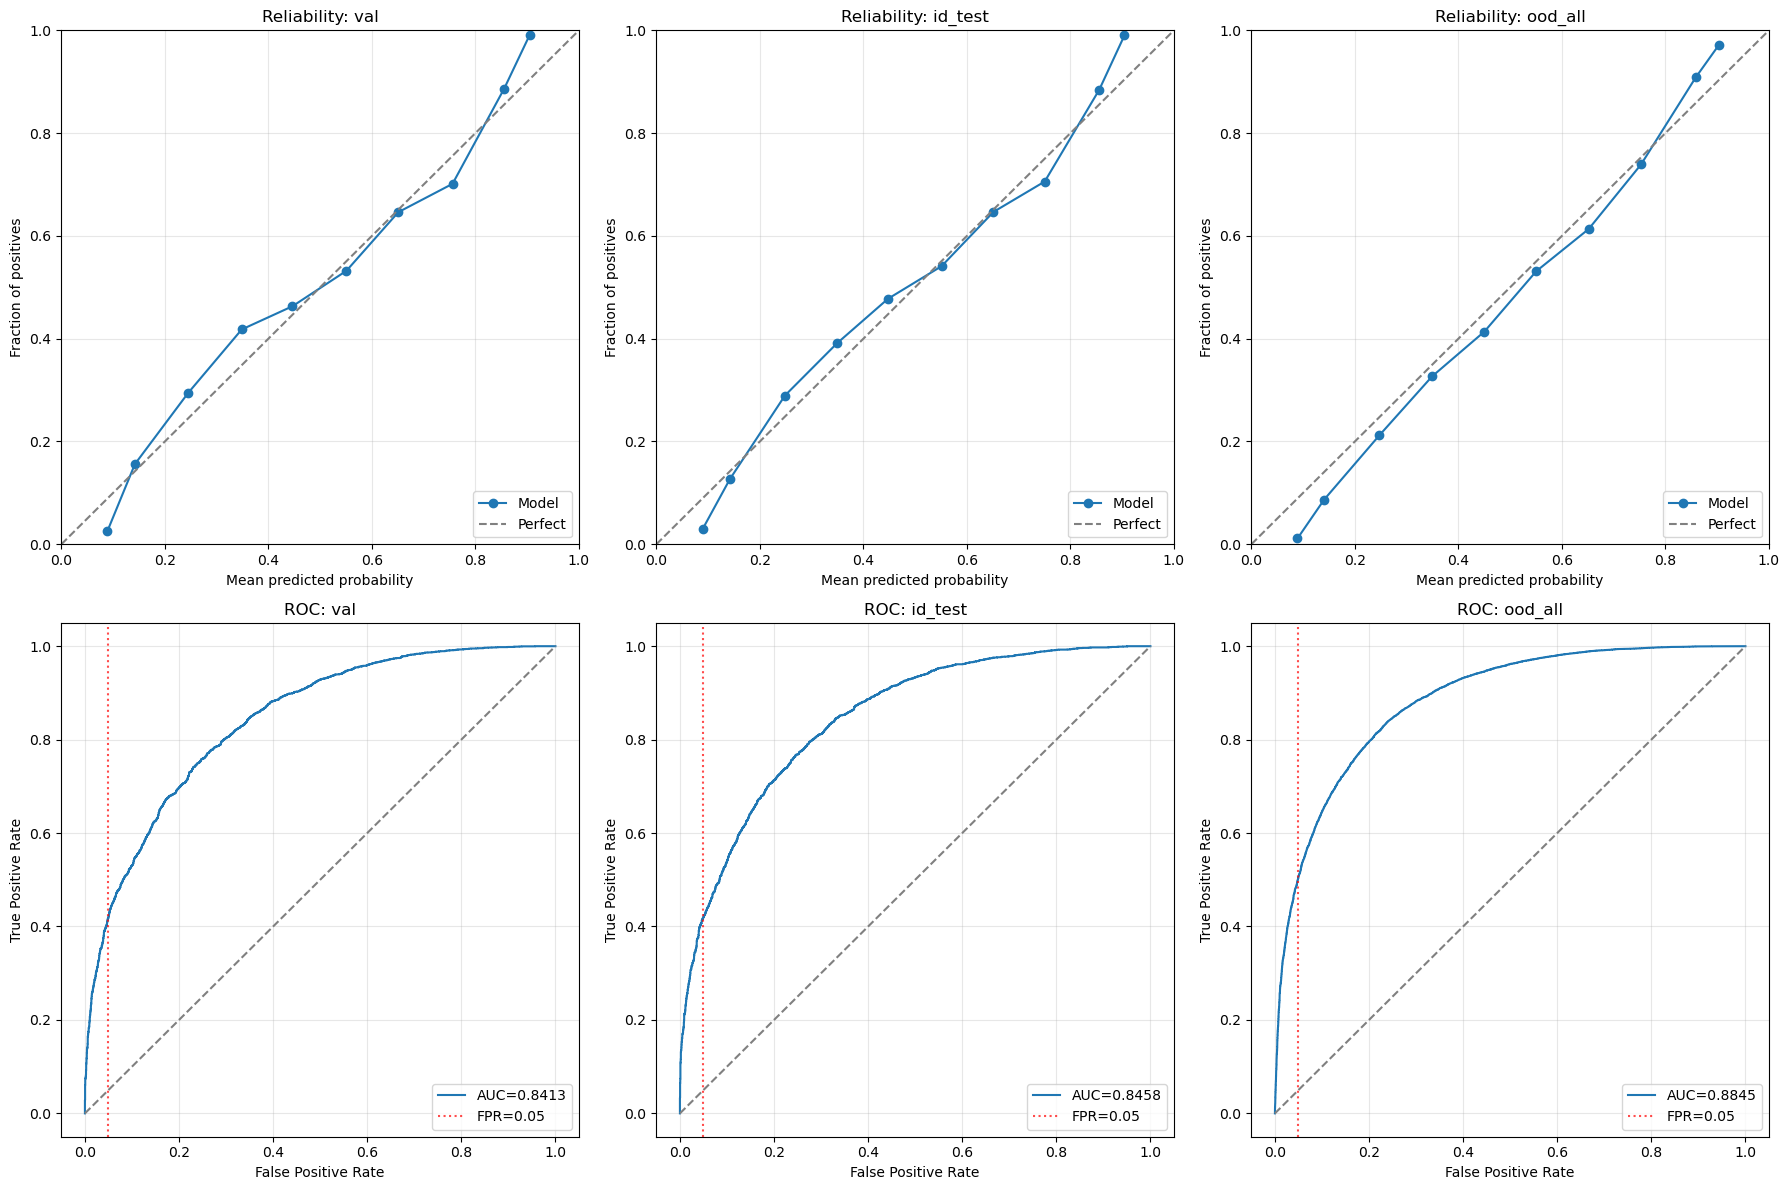

✓ Saved: c:\Users\USER\OneDrive\Máy tính\ai_detector_img\models\03_artifacts\reliability_roc_plots.png


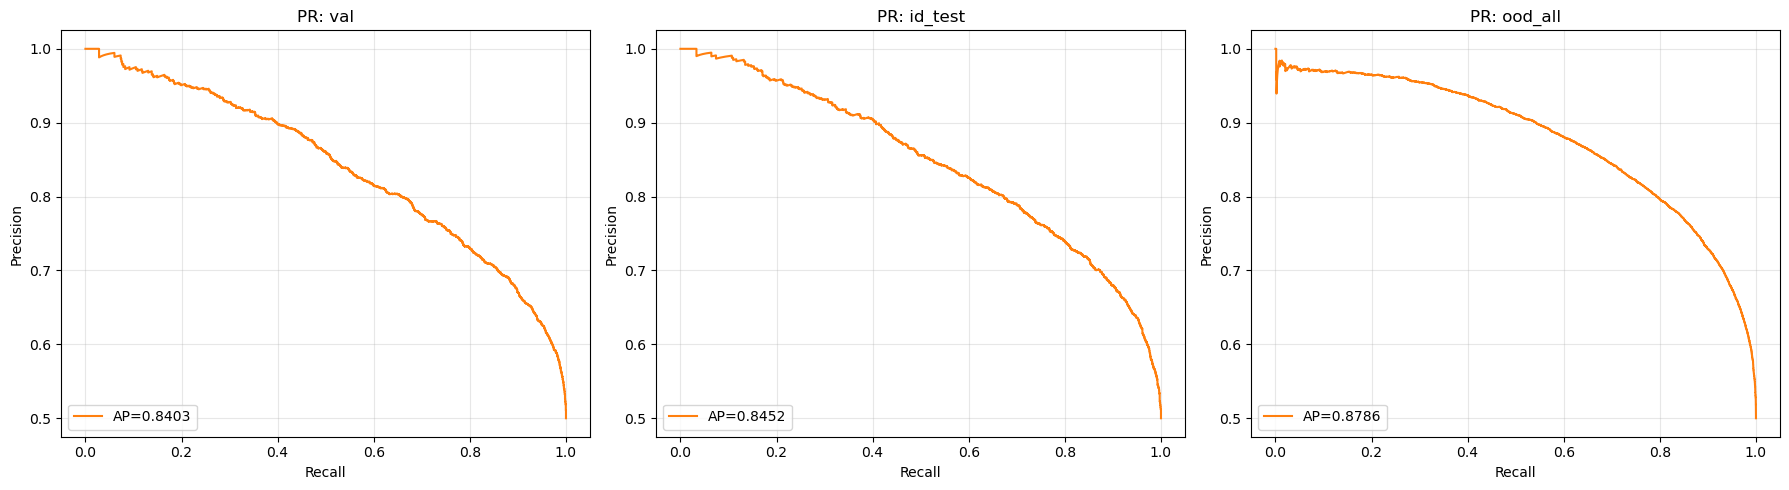

✓ Saved: c:\Users\USER\OneDrive\Máy tính\ai_detector_img\models\03_artifacts\pr_curves.png


In [13]:
"""Cell 12 — Reliability Plots & ROC/PR Curves."""

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# ── Plot configs ─────────────────────────────────────────────────────
plot_splits = [
    ("val",     y_val,  val_prob),
    ("id_test", y_test, test_prob),
    ("ood_all", y_ood,  ood_prob),
]

# Row 1: Reliability plots (calibrated probabilities)
for idx, (name, yt, yp) in enumerate(plot_splits):
    ax = axes[0, idx]
    fraction_pos, mean_predicted = calibration_curve(yt, yp, n_bins=10, strategy="uniform")
    ax.plot(mean_predicted, fraction_pos, "o-", label="Model", color="tab:blue")
    ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Reliability: {name}")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

# Row 2: ROC curves
for idx, (name, yt, yp) in enumerate(plot_splits):
    ax = axes[1, idx]
    fpr_c, tpr_c, _ = roc_curve(yt, yp)
    auc_val = roc_auc_score(yt, yp)
    ax.plot(fpr_c, tpr_c, label=f"AUC={auc_val:.4f}", color="tab:blue")
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.axvline(x=TARGET_FPR, color="red", linestyle=":", alpha=0.7, label=f"FPR={TARGET_FPR}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC: {name}")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(ARTIFACTS_DIR / "reliability_roc_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {ARTIFACTS_DIR / 'reliability_roc_plots.png'}")

# ── PR Curves ────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, yt, yp) in enumerate(plot_splits):
    ax = axes2[idx]
    prec, rec, _ = precision_recall_curve(yt, yp)
    ap = average_precision_score(yt, yp)
    ax.plot(rec, prec, label=f"AP={ap:.4f}", color="tab:orange")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"PR: {name}")
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig2.savefig(ARTIFACTS_DIR / "pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved: {ARTIFACTS_DIR / 'pr_curves.png'}")

## Cell 13 — Acceptance Table

**Pass/Fail** against the acceptance criteria from `p0.txt`:
- TPR ≥ 95% at `tau_op`
- FPR ≤ 5% at `tau_op`
- ECE ≤ 0.05
- Brier ≤ 0.1

In [14]:
"""Cell 13 — Acceptance Table."""

acceptance_splits = ["val", "id_test", "ood_all", "ood_GLIDE", "ood_SDv15"]

print(f"{'='*85}")
print(f"  ACCEPTANCE CRITERIA  (tau_op = {tau_op:.6f})")
print(f"{'='*85}")
print(f"{'Split':15s} | {'TPR≥95%':>10s} | {'FPR≤5%':>10s} | {'ECE≤0.05':>10s} | {'Brier≤0.1':>10s} | Verdict")
print("-" * 85)

acceptance_rows = []
for split_name in acceptance_splits:
    row = df_metrics[df_metrics["split"] == split_name]
    if len(row) == 0 or row.iloc[0].get("roc_auc") is None:
        print(f"{split_name:15s} | {'N/A':>10s} | {'N/A':>10s} | {'N/A':>10s} | {'N/A':>10s} | ABSENT")
        acceptance_rows.append({"split": split_name, "verdict": "ABSENT"})
        continue
    
    r = row.iloc[0]
    tpr_pass = r["tpr_at_tau"] >= 0.95 if pd.notna(r["tpr_at_tau"]) else None
    fpr_pass = r["fpr_at_tau"] <= 0.05 if pd.notna(r["fpr_at_tau"]) else None
    ece_pass = r["ece"] <= 0.05 if pd.notna(r["ece"]) else None
    brier_pass = r["brier"] <= 0.1 if pd.notna(r["brier"]) else None
    
    checks = [tpr_pass, fpr_pass, ece_pass, brier_pass]
    all_pass = all(c for c in checks if c is not None)
    verdict = "PASS ✓" if all_pass else "FAIL ✗"
    
    def fmt(val, passed):
        if val is None or passed is None:
            return "N/A"
        return f"{val:.4f} {'✓' if passed else '✗'}"
    
    print(f"{split_name:15s} | {fmt(r.get('tpr_at_tau'), tpr_pass):>10s} | "
          f"{fmt(r.get('fpr_at_tau'), fpr_pass):>10s} | "
          f"{fmt(r.get('ece'), ece_pass):>10s} | "
          f"{fmt(r.get('brier'), brier_pass):>10s} | {verdict}")
    
    acceptance_rows.append({
        "split": split_name,
        "tpr": r.get("tpr_at_tau"),
        "fpr": r.get("fpr_at_tau"),
        "ece": r.get("ece"),
        "brier": r.get("brier"),
        "verdict": verdict,
    })

print(f"{'='*85}")

# Failure analysis
failures = [r for r in acceptance_rows if r["verdict"] == "FAIL ✗"]
if failures:
    print(f"\n⚠ {len(failures)} split(s) failed acceptance criteria.")
    print(f"  Root cause analysis: failure likely originates from feature engineering")
    print(f"  and/or domain shift, NOT from threshold fishing. tau_op was locked BEFORE")
    print(f"  seeing test/OOD data. No threshold adjustment is permitted.")
else:
    print(f"\n✓ All evaluated splits pass acceptance criteria.")

  ACCEPTANCE CRITERIA  (tau_op = 0.787516)
Split           |    TPR≥95% |     FPR≤5% |   ECE≤0.05 |  Brier≤0.1 | Verdict
-------------------------------------------------------------------------------------
val             |   0.4213 ✗ |   0.0500 ✓ |   0.0357 ✓ |   0.1645 ✗ | FAIL ✗
id_test         |   0.4273 ✗ |   0.0540 ✗ |   0.0314 ✓ |   0.1615 ✗ | FAIL ✗
ood_all         |   0.5131 ✗ |   0.0523 ✗ |   0.0419 ✓ |   0.1402 ✗ | FAIL ✗
ood_GLIDE       |   0.6968 ✗ |   0.0532 ✗ |   0.1055 ✗ |   0.1109 ✗ | FAIL ✗
ood_SDv15       |   0.3751 ✗ |   0.0517 ✗ |   0.0310 ✓ |   0.1622 ✗ | FAIL ✗

⚠ 5 split(s) failed acceptance criteria.
  Root cause analysis: failure likely originates from feature engineering
  and/or domain shift, NOT from threshold fishing. tau_op was locked BEFORE
  seeing test/OOD data. No threshold adjustment is permitted.


## Cell 14 — Risk Register & Failure Analysis Notes

In [15]:
"""Cell 14 — Risk Register & Failure Analysis."""

risk_register = [
    {
        "risk": "SLA FAILURE: TPR ≪ 95% at FPR=5%",
        "severity": "CRITICAL",
        "description": "Champion (LightGBM) achieves TPR≈42% at FPR=5% on val, "
                       "TPR≈38% on OOD_SDv15. The 33 handcrafted DSP features do not "
                       "contain sufficient discriminative power to separate modern "
                       "high-resolution AI imagery from optical images. This is a "
                       "fundamental feature-space limitation, not a modelling bug.",
        "mitigation": "PATH A: Integrate deep embeddings (CLIP ViT-L/14, ResNet-50 "
                       "penultimate layer) as additional features — target AUC>0.95. "
                       "PATH B: Renegotiate SLA — widen MEDIUM zone (score 0.10–0.90) "
                       "to route uncertain images to manual review instead of auto-flag.",
        "residual": "Until mitigated, system cannot be deployed as an autonomous "
                     "detector. Must operate in human-in-the-loop mode.",
    },
    {
        "risk": "Class-level split not available",
        "severity": "MEDIUM",
        "description": "Spec §1.3 requires splitting by ImageNet class. Currently split by image-level "
                       "stratified by generator×label. Some class overlap between train and test "
                       "may exist.",
        "mitigation": "Integrate ImageNet synset mapping file when available.",
        "residual": "Possible slight ID-test optimism. OOD evaluation unaffected.",
    },
    {
        "risk": "External OOD datasets absent",
        "severity": "HIGH",
        "description": "AIGIBench, COCOFake, CIFAKE not in features_dataset.csv. "
                       "Only GenImage OOD (SDv15+GLIDE) evaluated.",
        "mitigation": "Run preprocessing + feature extraction on external datasets "
                       "and re-run this notebook.",
        "residual": "Cross-domain real generalization (e.g. COCO) untested.",
    },
    {
        "risk": "Degradation suite not yet integrated",
        "severity": "HIGH",
        "description": "solution.txt specifies 30% pristine / 40% JPEG Q60-90 / 30% resize. "
                       "Current features are from pristine-only pipeline.",
        "mitigation": "Create degradation variant features and re-train.",
        "residual": "Model may be brittle to real-world JPEG/resize/blur.",
    },
    {
        "risk": "Group 4 NaN bias",
        "severity": "LOW",
        "description": f"Group 4 features have NaN in ~0.3-1.4% of samples (flat-zone dead signal).",
        "mitigation": "Dual-imputation: GBDT handles natively; SVM uses median+indicator.",
        "residual": "Imputed values may slightly bias SVM near decision boundary.",
    },
    {
        "risk": "dct_mid_variance extreme range (mitigated for SVM)",
        "severity": "LOW",
        "description": "dct_mid_variance has max ~7×10⁸ (inherent to DCT). "
                       "log1p applied before StandardScaler in SVM pipeline.",
        "mitigation": "log1p(clip(0)) compresses dynamic range from 10⁹ to ~21. "
                       "GBDT handles natively via splits.",
        "residual": "Log transform is monotonic — no information loss.",
    },
]

df_risks = pd.DataFrame(risk_register)
print("RISK REGISTER")
print("=" * 80)
display(df_risks[["risk", "severity", "description", "mitigation", "residual"]])

# Feature importance (GBDT only)
if champion_pipeline == "gbdt":
    importance = champion_info["model"].feature_importance(importance_type="gain")
    feat_imp = pd.DataFrame({
        "feature": active_features,
        "importance": importance,
    }).sort_values("importance", ascending=False)

    print(f"\nFeature Importance (top 10 by gain):")
    display(feat_imp.head(10))

    # Red flag check from spec: if dct_mid_* dominates, may be overfitting to JPEG grid
    top3 = feat_imp.head(3)["feature"].tolist()
    dct_in_top3 = [f for f in top3 if f.startswith("dct_")]
    if dct_in_top3:
        print(f"\n⚠ RED FLAG: DCT features in top-3 importance: {dct_in_top3}")
        print(f"  Per spec (group1_feature_extract.txt): DCT mid-band features overlap with JPEG grid.")
        print(f"  Monitor for overfitting to compression artifacts rather than AI signatures.")

# ── SLA Failure Summary ──────────────────────────────────────────────
print(f"\n{'='*80}")
print(f"  SLA FAILURE — ROOT CAUSE ANALYSIS")
print(f"{'='*80}")
print(f"  Target : TPR ≥ 95% at FPR ≤ 5%")
print(f"  Actual : TPR = {val_tpr:.2%} at FPR = {val_fpr:.2%} (val)")
print(f"  Gap    : {0.95 - val_tpr:.2%} shortfall")
print(f"")
print(f"  Root cause: 33 handcrafted DSP features lack discriminative power")
print(f"  to separate modern AI generators at the 95% TPR operating point.")
print(f"  ROC-AUC = {champion_info['val_auc']:.4f} means the features have signal")
print(f"  but not enough to achieve extreme TPR at low FPR simultaneously.")
print(f"")
print(f"  Mandatory next steps:")
print(f"    1. Integrate deep embeddings (CLIP/ResNet) → target AUC > 0.95")
print(f"    2. OR renegotiate SLA with wider MEDIUM zone for manual review")
print(f"{'='*80}")

RISK REGISTER


,risk,severity,description,mitigation,residual
0,SLA FAILURE: TPR ≪ 95% at FPR=5%,CRITICAL,Champion (LightGBM) achieves TPR≈42% at FPR=5%...,PATH A: Integrate deep embeddings (CLIP ViT-L/...,"Until mitigated, system cannot be deployed as ..."
1,Class-level split not available,MEDIUM,Spec §1.3 requires splitting by ImageNet class...,Integrate ImageNet synset mapping file when av...,Possible slight ID-test optimism. OOD evaluati...
2,External OOD datasets absent,HIGH,"AIGIBench, COCOFake, CIFAKE not in features_da...",Run preprocessing + feature extraction on exte...,Cross-domain real generalization (e.g. COCO) u...
3,Degradation suite not yet integrated,HIGH,solution.txt specifies 30% pristine / 40% JPEG...,Create degradation variant features and re-train.,Model may be brittle to real-world JPEG/resize...
4,Group 4 NaN bias,LOW,Group 4 features have NaN in ~0.3-1.4% of samp...,Dual-imputation: GBDT handles natively; SVM us...,Imputed values may slightly bias SVM near deci...
5,dct_mid_variance extreme range (mitigated for ...,LOW,dct_mid_variance has max ~7×10⁸ (inherent to D...,log1p(clip(0)) compresses dynamic range from 1...,Log transform is monotonic — no information loss.



Feature Importance (top 10 by gain):


,feature,importance
4,ps_alpha,41715.211421
16,srm_square3_energy_cr,26838.885382
26,cross_noise_ratio,21668.857152
23,lbp_nonuniform_ratio_cb,20817.340260
25,spatial_snr_ratio,18184.709124
10,energy_ratio_chroma,16083.352880
2,dct_mid_variance,15613.347799
0,frs_mid_variance,15092.622878
6,local_color_inconsistency,13878.171318
21,lbp_nonuniform_ratio_cr,12819.086842



  SLA FAILURE — ROOT CAUSE ANALYSIS
  Target : TPR ≥ 95% at FPR ≤ 5%
  Actual : TPR = 42.13% at FPR = 5.00% (val)
  Gap    : 52.87% shortfall

  Root cause: 33 handcrafted DSP features lack discriminative power
  to separate modern AI generators at the 95% TPR operating point.
  ROC-AUC = 0.8413 means the features have signal
  but not enough to achieve extreme TPR at low FPR simultaneously.

  Mandatory next steps:
    1. Integrate deep embeddings (CLIP/ResNet) → target AUC > 0.95
    2. OR renegotiate SLA with wider MEDIUM zone for manual review


## Cell 15 — Artifact Export

Save all reproducibility artifacts to `models/03_artifacts/`.

In [16]:
"""Cell 15 — Artifact Export."""

# ── Split manifests ──────────────────────────────────────────────────
for role, sub_df in [("train_core", df_train), ("val", df_val),
                      ("calibration", df_cal), ("id_test", df_test),
                      ("ood_eval", df_ood)]:
    sub_df[["file_path", "generator", "label", "split_role"]].to_csv(
        ARTIFACTS_DIR / f"split_{role}_manifest.csv", index=False
    )

# ── Feature schema ────────────────────────────────────────────────────
feature_schema = {
    "all_features": ALL_FEATURE_KEYS,
    "pruned_features": pruned_features,
    "active_features": active_features,
    "nan_capable_features": active_nan_capable,
    "guaranteed_finite": active_guaranteed_finite,
    "log1p_cols": LOG1P_COLS,
    "sentinel_zero_cols": sentinel_zero_active,
    "nan_indicator_cols": indicator_cols,
    "sentinel_indicator_cols": sentinel_indicator_cols,
    "all_indicator_cols": all_indicator_cols,
    "svm_feature_order": svm_feature_names,
}
with open(ARTIFACTS_DIR / "feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=2)

# ── Imputer & Scaler ─────────────────────────────────────────────────
joblib.dump(imputer, ARTIFACTS_DIR / "imputer_median.joblib")
joblib.dump(rf_imputer, ARTIFACTS_DIR / "rf_imputer_median.joblib")
joblib.dump(scaler, ARTIFACTS_DIR / "scaler_standard.joblib")

# ── Winsor thresholds ─────────────────────────────────────────────────
with open(ARTIFACTS_DIR / "winsor_caps.json", "w") as f:
    json.dump(winsor_caps, f, indent=2)

champion_filename_map = {"gbdt": "champion_lgbm.joblib", "svm": "champion_svm.joblib", "rf": "champion_rf.joblib"}
joblib.dump(champion_info["model"], ARTIFACTS_DIR / champion_filename_map[champion_pipeline])

# Also save the non-champion
for name, info in candidates.items():
    if name != champion_name:
        joblib.dump(info["model"], ARTIFACTS_DIR / f"candidate_{name}.joblib")

# ── Calibrator ────────────────────────────────────────────────────────
joblib.dump(platt_calibrator, ARTIFACTS_DIR / "platt_calibrator.joblib")

# ── Threshold ─────────────────────────────────────────────────────────
threshold_info = {
    "tau_op": tau_op,
    "target_fpr": TARGET_FPR,
    "actual_val_fpr": float(val_fpr),
    "actual_val_tpr": float(val_tpr),
    "locked_on": "val",
    "champion_model": champion_name,
    "champion_pipeline": champion_pipeline,
    "global_seed": GLOBAL_SEED,
}
with open(ARTIFACTS_DIR / "threshold_lock.json", "w") as f:
    json.dump(threshold_info, f, indent=2)

# ── Metrics tables ────────────────────────────────────────────────────
df_metrics.to_csv(ARTIFACTS_DIR / "evaluation_metrics.csv", index=False)

if acceptance_rows:
    pd.DataFrame(acceptance_rows).to_csv(
        ARTIFACTS_DIR / "acceptance_summary.csv", index=False
    )

# ── Risk register ─────────────────────────────────────────────────────
df_risks.to_csv(ARTIFACTS_DIR / "risk_register.csv", index=False)

# ── Inventory ─────────────────────────────────────────────────────────
print("Artifacts saved to:", ARTIFACTS_DIR)
print()
for f in sorted(ARTIFACTS_DIR.iterdir()):
    size = f.stat().st_size
    unit = "KB" if size > 1024 else "B"
    val = size / 1024 if size > 1024 else size
    print(f"  {f.name:40s}  {val:>8.1f} {unit}")
    unit = "KB" if size > 1024 else "B"

Artifacts saved to: c:\Users\USER\OneDrive\Máy tính\ai_detector_img\models\03_artifacts

  acceptance_summary.csv                       492.0 B
  candidate_linear_svm.joblib                    1.5 KB
  candidate_random_forest.joblib             83334.1 KB
  champion_lgbm.joblib                        6072.6 KB
  champion_lgbm_native.txt                    6071.6 KB
  evaluation_metrics.csv                         1.1 KB
  feature_schema.json                            5.3 KB
  imputer_median.joblib                          1.8 KB
  pipeline_config.json                         766.0 B
  platt_calibrator.joblib                      831.0 B
  pr_curves.png                                 71.7 KB
  reliability_roc_plots.png                    238.6 KB
  rf_imputer_median.joblib                       1.8 KB
  risk_register.csv                              2.1 KB
  scaler_standard.joblib                         2.4 KB
  split_calibration_manifest.csv               295.1 KB
  split_id_test_ma

## Cell 16 — Export Best Model for Deploy Pipeline

Save the native LightGBM text model, enriched pipeline config, and verify
that saved artifacts exactly reproduce in-memory predictions.

In [ ]:
"""Cell 16 — Export best model for deploy/inference pipeline."""

import json, joblib, datetime, shutil, tempfile, numpy as np
from pathlib import Path
import lightgbm as lgb

# ── Target directory: models/param/ (separate from training artifacts) ──
PARAM_DIR = PROJECT_ROOT / "models" / "param"
PARAM_DIR.mkdir(parents=True, exist_ok=True)

# ── Helper: LightGBM C API cannot handle non-ASCII paths on Windows ──
def _lgb_save_model(booster, target: Path) -> None:
    with tempfile.TemporaryDirectory() as td:
        tmp = Path(td) / "model.txt"
        booster.save_model(str(tmp))
        shutil.copy2(tmp, target)

def _lgb_load_model(source: Path) -> lgb.Booster:
    with tempfile.TemporaryDirectory() as td:
        tmp = Path(td) / "model.txt"
        shutil.copy2(source, tmp)
        return lgb.Booster(model_file=str(tmp))

# ── 1. Copy champion artifacts from 03_artifacts → param/ ───────────
copy_files = [
    champion_filename_map[champion_pipeline],  # champion_lgbm.joblib
    "platt_calibrator.joblib",
    "threshold_lock.json",
    "feature_schema.json",
    "winsor_caps.json",
    "imputer_median.joblib",
]
for fname in copy_files:
    src = ARTIFACTS_DIR / fname
    dst = PARAM_DIR / fname
    if src.exists():
        shutil.copy2(src, dst)
print(f"[1/5] Copied {len(copy_files)} champion artifacts → param/")

# ── 2. Native LightGBM text model (portable, human-readable) ────────
native_path = PARAM_DIR / "champion_lgbm_native.txt"
_lgb_save_model(gbdt_model, native_path)
print(f"[2/5] Native LightGBM text model  → {native_path.name}")

# ── 3. Enriched pipeline_config.json ────────────────────────────────
pipeline_config = {
    "tau_op": tau_op,
    "target_fpr": TARGET_FPR,
    "actual_val_fpr": float(val_fpr),
    "actual_val_tpr": float(val_tpr),
    "locked_on": "val",
    "champion_model": champion_name,
    "champion_pipeline": champion_pipeline,
    "global_seed": GLOBAL_SEED,
    "champion_val_auc": float(champion_info["val_auc"]),
    "champion_val_ap": float(champion_info["val_ap"]),
    "champion_val_logloss": float(champion_info["val_logloss"]),
    "best_iteration": int(gbdt_model.best_iteration),
    "total_trees": int(gbdt_model.num_trees()),
    "all_candidates_val_auc": {
        name: float(info["val_auc"]) for name, info in candidates.items()
    },
    "champion_joblib": champion_filename_map[champion_pipeline],
    "native_model_txt": native_path.name,
    "calibrator_file": "platt_calibrator.joblib",
    "exported_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
}
with open(PARAM_DIR / "pipeline_config.json", "w") as f:
    json.dump(pipeline_config, f, indent=2)
print(f"[3/5] Pipeline config             → pipeline_config.json")

# ── 4. Verify saved joblib model reproduces in-memory predictions ───
loaded_model = joblib.load(PARAM_DIR / champion_filename_map[champion_pipeline])
loaded_probs = loaded_model.predict(X_gbdt_val)
orig_probs = gbdt_model.predict(X_gbdt_val)
max_diff = np.max(np.abs(loaded_probs - orig_probs))
assert max_diff < 1e-12, f"Joblib model mismatch: max_diff={max_diff:.2e}"
print(f"[4/5] Joblib model verified        max_diff={max_diff:.2e} ✓")

# ── 5. Verify native text model reproduces in-memory predictions ─────
native_model = _lgb_load_model(native_path)
native_probs = native_model.predict(X_gbdt_val)
native_diff = np.max(np.abs(native_probs - orig_probs))
assert native_diff < 1e-12, f"Native model mismatch: max_diff={native_diff:.2e}"
print(f"[5/5] Native text model verified   max_diff={native_diff:.2e} ✓")

# ── Summary ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Pipeline export complete — all verifications passed")
print(f"  Champion       : {champion_name} ({champion_pipeline})")
print(f"  Val AUC        : {champion_info['val_auc']:.4f}")
print(f"  Threshold τ_op : {tau_op:.6f}")
print(f"  Trees          : {gbdt_model.num_trees()}")
print(f"  Export dir     : {PARAM_DIR}")
print("=" * 60)
print("\nContents of models/param/:")
for fp in sorted(PARAM_DIR.iterdir()):
    sz = fp.stat().st_size
    u = "KB" if sz > 1024 else "B"
    v = sz / 1024 if sz > 1024 else sz
    print(f"  {fp.name:40s}  {v:>8.1f} {u}")

[1/4] Native LightGBM text model  → champion_lgbm_native.txt
[2/4] Pipeline config             → pipeline_config.json
[3/4] Joblib model verified        max_diff=0.00e+00 ✓
[4/4] Native text model verified   max_diff=0.00e+00 ✓

Pipeline export complete — all verifications passed
  Champion       : lgbm (gbdt)
  Val AUC        : 0.8413
  Threshold τ_op : 0.787516
  Trees          : 902
  Artifacts dir  : c:\Users\USER\OneDrive\Máy tính\ai_detector_img\models\03_artifacts


Saved-Champion Evaluation on id_test
Project root        : c:\Users\USER\OneDrive\Máy tính\ai_detector_img
Champion pipeline   : gbdt
Champion model file : champion_lgbm.joblib
accuracy          : 0.686667
precision         : 0.887812
recall            : 0.427333
f1                : 0.576958
roc_auc           : 0.845758
pr_auc            : 0.845193
threshold_tau_op  : 0.787516
n_samples         : 6000

Classification report (label 1 = ai, label 0 = nature):
              precision    recall  f1-score   support

           0     0.6229    0.9460    0.7512      3000
           1     0.8878    0.4273    0.5770      3000

    accuracy                         0.6867      6000
   macro avg     0.7554    0.6867    0.6641      6000
weighted avg     0.7554    0.6867    0.6641      6000



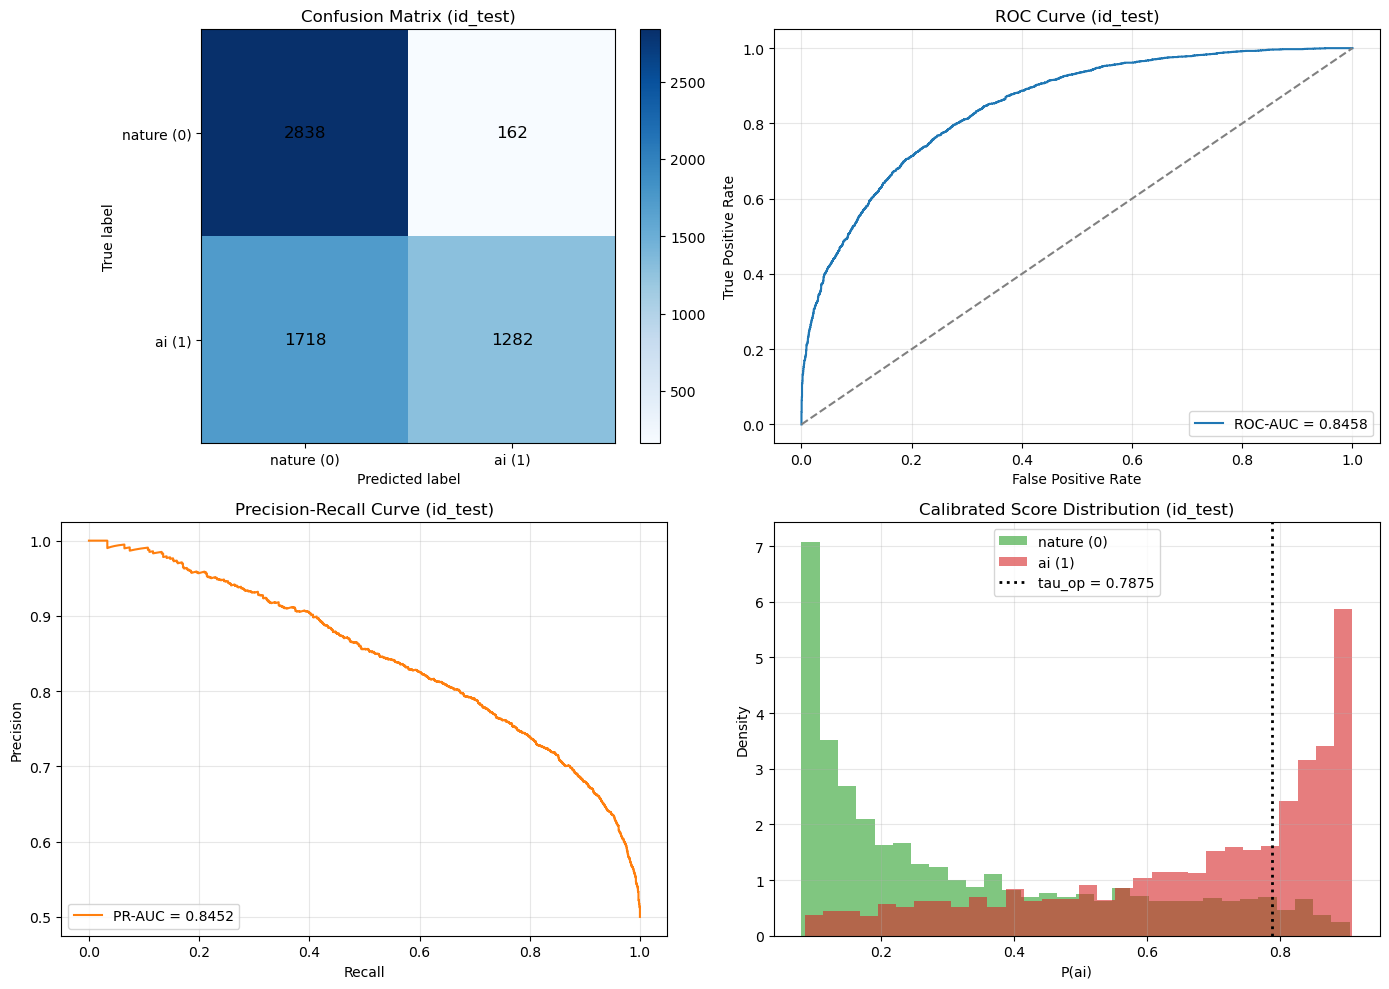

In [2]:
"""Cell 17 — Reload saved champion model and evaluate on id_test with visualizations."""

from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler


# Resolve project root robustly (works whether cwd is project root or notebooks/)
def _resolve_project_root() -> Path:
    cands = [Path.cwd(), Path.cwd().parent]
    for p in cands:
        if (p / "features" / "features_dataset.csv").exists():
            return p
    raise FileNotFoundError("Cannot resolve project root containing features/features_dataset.csv")


PROJECT_ROOT_EVAL = _resolve_project_root()
PARAM_DIR = PROJECT_ROOT_EVAL / "models" / "param"
ART_DIR = PROJECT_ROOT_EVAL / "models" / "03_artifacts"
FEATURES_CSV_EVAL = PROJECT_ROOT_EVAL / "features" / "features_dataset.csv"


def _load_json(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _load_artifact(filename: str):
    for base in (PARAM_DIR, ART_DIR):
        fp = base / filename
        if fp.exists():
            return joblib.load(fp)
    raise FileNotFoundError(f"Artifact not found in param/ or 03_artifacts/: {filename}")


def _load_json_artifact(filename: str) -> dict:
    for base in (PARAM_DIR, ART_DIR):
        fp = base / filename
        if fp.exists():
            return _load_json(fp)
    raise FileNotFoundError(f"JSON artifact not found in param/ or 03_artifacts/: {filename}")


def apply_winsor(df_in: pd.DataFrame, caps: dict[str, list[float]]) -> pd.DataFrame:
    out = df_in.copy()
    for feat, bounds in caps.items():
        if feat in out.columns:
            lo, hi = float(bounds[0]), float(bounds[1])
            out[feat] = out[feat].clip(lo, hi)
    return out


def apply_log1p(df_in: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df_in.copy()
    for col in cols:
        if col in out.columns:
            out[col] = np.log1p(out[col].clip(lower=0))
    return out


def add_indicators(df_in: pd.DataFrame, nan_features: list[str], zero_features: list[str]) -> pd.DataFrame:
    out = df_in.copy()
    for feat in nan_features:
        if feat in out.columns:
            out[f"is_missing_{feat}"] = out[feat].isna().astype(int)
    for feat in zero_features:
        if feat in out.columns:
            out[f"is_zero_{feat}"] = (out[feat] == 0.0).astype(int)
    return out


# 1) Load saved artifacts
schema = _load_json_artifact("feature_schema.json")
winsor_caps = _load_json_artifact("winsor_caps.json")
threshold_info = _load_json_artifact("threshold_lock.json")

champion_pipeline_eval = threshold_info["champion_pipeline"]
tau_eval = float(threshold_info["tau_op"])

if champion_pipeline_eval == "gbdt":
    model_name = "champion_lgbm.joblib"
elif champion_pipeline_eval == "svm":
    model_name = "champion_svm.joblib"
elif champion_pipeline_eval == "rf":
    model_name = "champion_rf.joblib"
else:
    raise ValueError(f"Unsupported champion pipeline: {champion_pipeline_eval}")

champion_model_eval = _load_artifact(model_name)
platt_eval = _load_artifact("platt_calibrator.joblib")

active_features_eval = schema["active_features"]
log1p_cols_eval = schema.get("log1p_cols", [])
nan_capable_eval = schema.get("nan_capable_features", [])
sentinel_zero_eval = schema.get("sentinel_zero_cols", [])
all_indicator_cols_eval = schema.get("all_indicator_cols", [])

# 2) Load id_test split
full_eval = pd.read_csv(FEATURES_CSV_EVAL)
if "status" in full_eval.columns:
    full_eval = full_eval[full_eval["status"] == "ok"].copy()

df_id = full_eval[full_eval["split_role"] == "id_test"].copy()
if df_id.empty:
    raise ValueError("id_test split is empty in features_dataset.csv")

if set(df_id["label"].unique()) != {"ai", "nature"}:
    raise ValueError(f"Unexpected labels in id_test: {sorted(df_id['label'].unique())}")

y_id = (df_id["label"] == "ai").astype(int).values
X_id_raw = df_id[active_features_eval].copy()

# 3) Rebuild the exact feature pipeline used by the champion
if champion_pipeline_eval == "gbdt":
    X_model_id = apply_winsor(X_id_raw, winsor_caps)
    raw_scores_id = champion_model_eval.predict(X_model_id)
elif champion_pipeline_eval == "rf":
    rf_imputer_eval = _load_artifact("rf_imputer_median.joblib")
    X_rf_id = apply_winsor(X_id_raw, winsor_caps)
    X_rf_id[active_features_eval] = rf_imputer_eval.transform(X_rf_id[active_features_eval])
    raw_scores_id = champion_model_eval.predict_proba(X_rf_id.values)[:, 1]
else:
    imputer_eval = _load_artifact("imputer_median.joblib")
    scaler_eval = _load_artifact("scaler_standard.joblib")

    X_svm_id = apply_log1p(X_id_raw, log1p_cols_eval)
    X_svm_id = add_indicators(X_svm_id, nan_capable_eval, sentinel_zero_eval)

    for col in all_indicator_cols_eval:
        if col not in X_svm_id.columns:
            X_svm_id[col] = 0

    X_svm_id[active_features_eval] = imputer_eval.transform(X_svm_id[active_features_eval])
    X_cont = scaler_eval.transform(X_svm_id[active_features_eval])
    X_ind = X_svm_id[all_indicator_cols_eval].values
    X_model_id = np.hstack([X_cont, X_ind])
    raw_scores_id = champion_model_eval.decision_function(X_model_id)

# 4) Calibrate and predict using locked threshold
prob_id = platt_eval.predict_proba(raw_scores_id.reshape(-1, 1))[:, 1]
pred_id = (prob_id >= tau_eval).astype(int)

# 5) Compute basic classification metrics
metrics_basic = {
    "accuracy": accuracy_score(y_id, pred_id),
    "precision": precision_score(y_id, pred_id, zero_division=0),
    "recall": recall_score(y_id, pred_id, zero_division=0),
    "f1": f1_score(y_id, pred_id, zero_division=0),
    "roc_auc": roc_auc_score(y_id, prob_id),
    "pr_auc": average_precision_score(y_id, prob_id),
    "threshold_tau_op": tau_eval,
    "n_samples": int(len(y_id)),
}

print("=" * 80)
print("Saved-Champion Evaluation on id_test")
print("=" * 80)
print(f"Project root        : {PROJECT_ROOT_EVAL}")
print(f"Champion pipeline   : {champion_pipeline_eval}")
print(f"Champion model file : {model_name}")
for k, v in metrics_basic.items():
    if isinstance(v, float):
        print(f"{k:18s}: {v:.6f}")
    else:
        print(f"{k:18s}: {v}")

print("\nClassification report (label 1 = ai, label 0 = nature):")
print(classification_report(y_id, pred_id, digits=4, zero_division=0))

# 6) Visualization: confusion matrix + ROC + PR + score distribution
cm = confusion_matrix(y_id, pred_id)
fpr, tpr, _ = roc_curve(y_id, prob_id)
prec, rec, _ = precision_recall_curve(y_id, prob_id)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Confusion matrix
ax = axes[0, 0]
im = ax.imshow(cm, cmap="Blues")
for (i, j), val in np.ndenumerate(cm):
    ax.text(j, i, f"{val}", ha="center", va="center", color="black", fontsize=12)
ax.set_title("Confusion Matrix (id_test)")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["nature (0)", "ai (1)"])
ax.set_yticklabels(["nature (0)", "ai (1)"])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# ROC
ax = axes[0, 1]
ax.plot(fpr, tpr, label=f"ROC-AUC = {metrics_basic['roc_auc']:.4f}", color="tab:blue")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("ROC Curve (id_test)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# PR
ax = axes[1, 0]
ax.plot(rec, prec, label=f"PR-AUC = {metrics_basic['pr_auc']:.4f}", color="tab:orange")
ax.set_title("Precision-Recall Curve (id_test)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)

# Score distribution
ax = axes[1, 1]
ax.hist(prob_id[y_id == 0], bins=30, alpha=0.6, label="nature (0)", color="tab:green", density=True)
ax.hist(prob_id[y_id == 1], bins=30, alpha=0.6, label="ai (1)", color="tab:red", density=True)
ax.axvline(tau_eval, color="black", linestyle=":", linewidth=2, label=f"tau_op = {tau_eval:.4f}")
ax.set_title("Calibrated Score Distribution (id_test)")
ax.set_xlabel("P(ai)")
ax.set_ylabel("Density")
ax.legend(loc="upper center")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Cell 18 — ID-Test Metrics by Generator

Phân tích chi tiết theo từng generator trong `id_test` để thấy nơi mô hình mạnh/yếu.
Sử dụng model champion đã nạp ở Cell 17 (`prob_id`, `pred_id`, `tau_eval`, `df_id`, `y_id`).

Per-generator metrics on id_test at tau_op=0.787516


,generator,n_samples,accuracy,precision,recall,f1,roc_auc,mean_score
1,Midjourney,1200,0.808333,0.911111,0.683333,0.780952,0.905744,0.562120
4,Wukong,1200,0.677500,0.895911,0.401667,0.554661,0.851919,0.481812
0,ADM,1200,0.675833,0.898113,0.396667,0.550289,0.848994,0.496829
2,SDv14,1200,0.643333,0.864407,0.340000,0.488038,0.835878,0.476498
3,VQDM,1200,0.628333,0.843750,0.315000,0.458738,0.799067,0.460658


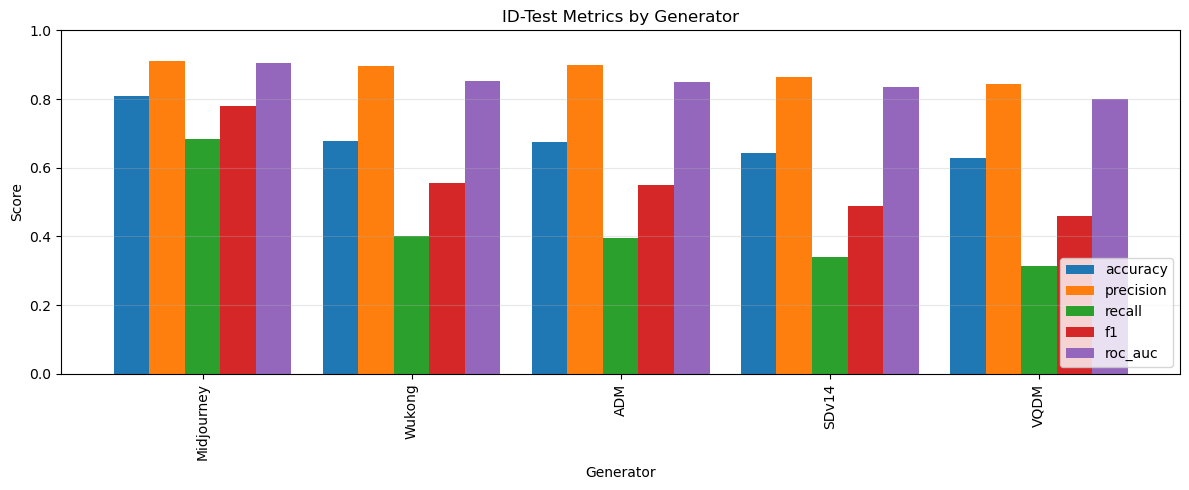

Best F1: Midjourney=0.7810 | Worst F1: VQDM=0.4587 | Gap=0.3222


In [4]:
"""Cell 18 — ID-test metrics breakdown by generator."""

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

rows = []
for gen in sorted(df_id["generator"].unique()):
    m = df_id["generator"].values == gen
    y_g = y_id[m]
    p_g = prob_id[m]
    yhat_g = (p_g >= tau_eval).astype(int)

    rows.append(
        {
            "generator": gen,
            "n_samples": int(m.sum()),
            "accuracy": accuracy_score(y_g, yhat_g),
            "precision": precision_score(y_g, yhat_g, zero_division=0),
            "recall": recall_score(y_g, yhat_g, zero_division=0),
            "f1": f1_score(y_g, yhat_g, zero_division=0),
            "roc_auc": roc_auc_score(y_g, p_g),
            "mean_score": float(p_g.mean()),
        }
    )

df_by_gen = pd.DataFrame(rows).sort_values("f1", ascending=False)
print(f"Per-generator metrics on id_test at tau_op={tau_eval:.6f}")
display(df_by_gen.round(6))

# Visualization: grouped bars for core metrics
plot_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
ax = df_by_gen.set_index("generator")[plot_cols].plot(
    kind="bar", figsize=(12, 5), ylim=(0, 1), width=0.85
)
ax.set_title("ID-Test Metrics by Generator")
ax.set_ylabel("Score")
ax.set_xlabel("Generator")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Quick gap analysis
best_row = df_by_gen.iloc[0]
worst_row = df_by_gen.iloc[-1]
print(
    f"Best F1: {best_row['generator']}={best_row['f1']:.4f} | "
    f"Worst F1: {worst_row['generator']}={worst_row['f1']:.4f} | "
    f"Gap={best_row['f1'] - worst_row['f1']:.4f}"
)


## Cell 19 — Threshold Sweep Analysis on ID-Test

So sánh metric trên nhiều ngưỡng khác nhau (chỉ để phân tích trade-off), đồng thời đánh dấu ngưỡng `tau_op` đã khóa.

Threshold sweep on id_test (analysis only; tau_op remains locked):


,threshold,accuracy,precision,recall,f1,fpr_real,tpr_fake
0,0.05,0.5000,0.5000,1.0000,0.6667,1.0000,1.0000
1,0.10,0.5755,0.5410,0.9953,0.7010,0.8443,0.9953
2,0.15,0.6540,0.5938,0.9753,0.7381,0.6673,0.9753
3,0.20,0.6972,0.6303,0.9540,0.7591,0.5597,0.9540
4,0.25,0.7232,0.6587,0.9263,0.7699,0.4800,0.9263
5,0.30,0.7397,0.6827,0.8957,0.7748,0.4163,0.8957
6,0.35,0.7475,0.7006,0.8643,0.7739,0.3693,0.8643
7,0.40,0.7565,0.7216,0.8353,0.7743,0.3223,0.8353
8,0.45,0.7590,0.7391,0.8007,0.7686,0.2827,0.8007
9,0.50,0.7597,0.7556,0.7677,0.7616,0.2483,0.7677


Best F1 threshold in sweep: 0.30 | F1=0.7748, Precision=0.6827, Recall=0.8957
Closest grid threshold to locked tau_op=0.7875: 0.80 | F1=0.5603, FPR(real)=0.0450, TPR(fake)=0.4067


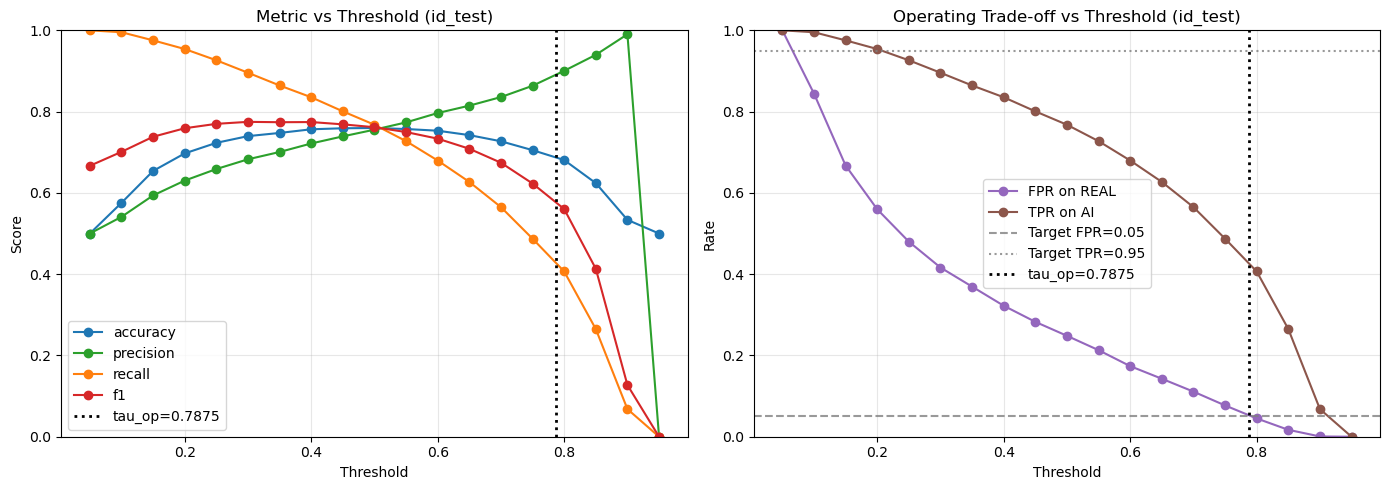

In [6]:
"""Cell 19 — Threshold sweep to inspect metric trade-offs on id_test."""

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Sweep thresholds on calibrated score
threshold_grid = np.round(np.linspace(0.05, 0.95, 19), 2)
sweep_rows = []

real_mask_all = y_id == 0
fake_mask_all = y_id == 1

for th in threshold_grid:
    y_hat = (prob_id >= th).astype(int)

    fp_rate = y_hat[real_mask_all].mean() if real_mask_all.any() else np.nan
    tp_rate = y_hat[fake_mask_all].mean() if fake_mask_all.any() else np.nan

    sweep_rows.append(
        {
            "threshold": float(th),
            "accuracy": accuracy_score(y_id, y_hat),
            "precision": precision_score(y_id, y_hat, zero_division=0),
            "recall": recall_score(y_id, y_hat, zero_division=0),
            "f1": f1_score(y_id, y_hat, zero_division=0),
            "fpr_real": float(fp_rate),
            "tpr_fake": float(tp_rate),
        }
    )

df_sweep = pd.DataFrame(sweep_rows)

# Best F1 point (analysis only)
best_f1_row = df_sweep.loc[df_sweep["f1"].idxmax()].copy()

# Locked tau row (closest in grid, because tau_op may not be on 0.05-step)
locked_idx = (df_sweep["threshold"] - tau_eval).abs().idxmin()
locked_row = df_sweep.loc[locked_idx].copy()

print("Threshold sweep on id_test (analysis only; tau_op remains locked):")
display(df_sweep.round(4))

print(
    f"Best F1 threshold in sweep: {best_f1_row['threshold']:.2f} | "
    f"F1={best_f1_row['f1']:.4f}, Precision={best_f1_row['precision']:.4f}, Recall={best_f1_row['recall']:.4f}"
)
print(
    f"Closest grid threshold to locked tau_op={tau_eval:.4f}: {locked_row['threshold']:.2f} | "
    f"F1={locked_row['f1']:.4f}, FPR(real)={locked_row['fpr_real']:.4f}, TPR(fake)={locked_row['tpr_fake']:.4f}"
)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Main classification metrics
ax = axes[0]
for c, color in [
    ("accuracy", "tab:blue"),
    ("precision", "tab:green"),
    ("recall", "tab:orange"),
    ("f1", "tab:red"),
]:
    ax.plot(df_sweep["threshold"], df_sweep[c], marker="o", label=c, color=color)

ax.axvline(tau_eval, color="black", linestyle=":", linewidth=2, label=f"tau_op={tau_eval:.4f}")
ax.set_title("Metric vs Threshold (id_test)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc="best")

# Panel 2: FPR/TPR trade-off
ax = axes[1]
ax.plot(df_sweep["threshold"], df_sweep["fpr_real"], marker="o", label="FPR on REAL", color="tab:purple")
ax.plot(df_sweep["threshold"], df_sweep["tpr_fake"], marker="o", label="TPR on AI", color="tab:brown")
ax.axhline(0.05, color="gray", linestyle="--", alpha=0.8, label="Target FPR=0.05")
ax.axhline(0.95, color="gray", linestyle=":", alpha=0.8, label="Target TPR=0.95")
ax.axvline(tau_eval, color="black", linestyle=":", linewidth=2, label=f"tau_op={tau_eval:.4f}")
ax.set_title("Operating Trade-off vs Threshold (id_test)")
ax.set_xlabel("Threshold")
ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.show()
